# Tutorial

I have run my model (or am running my model now) and want to see how it looks! Follow these steps.

In [1]:
import ocean_skill as osk
from ocean_skill.build import build_kerchunk, build_catalog, discover_opendap_files, new_catalog, add_erddap_source, save


## Are you running on Anvil or Tanagra?

In [2]:
host = "anvil"

## Catalogs

I am using the `intake` package concept of a catalog to represent and interact with model output and datasets. A catalog is a yaml file and it has one or more sources, which are the individual model or datasets, and include metadata that allows us to quickly search for known datasets by text, location, time, variable, etc. Anyone can write a catalog to add to a shared or personal catalog directory, though I expect I will write many of them to start. The code to write a catalog is pretty simple for well-served, standardized datasets, and can be messy for more unique datasets with unusual variable names. Ideally all of our catalogs will be stand alone files.


Catalogs will automatically be found in any of four locations and have a hierarchy according to their location.

| Priority | Location | How to set it up | Defaults to | Notes |
|---|---|---|---|---|
| 1 (lowest) | Packaged — `ocean_skill/catalogs/` | Ships with the package install | 8 reference catalogs for now (WOA, GLODAP, MODIS Aqua, etc.) | |
| 2 | Shared/team) | `$OCEAN_SKILL_CATALOGS` env var or `osk.catalog.add_search_path(dir)` in code | Nothing | On Anvil. For a cluster module file, team `.bashrc`, or a notebook registering a group directory |
| 3 | User | Drop YAML files in `~/.ocean-skill/catalogs/` | Nothing | Same path on macOS/Linux/Windows |
| 4 (highest) | Project-local | `./catalogs/` in your project (auto-discovered, gitignored) | Nothing | Unchanged; wins because it's the narrowest scope |

Check search paths:

In [3]:
osk.catalog.search_paths()

[PosixPath('/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs'),
 PosixPath('/home/kthyng/.config/ocean-skill/catalogs'),
 PosixPath('/home/kthyng/.ocean-skill/catalogs'),
 PosixPath('/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/catalogs'),
 PosixPath('/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/docs/catalogs')]

Modify catalog search paths on Anvil to have shared directory:

In [4]:
if host == "anvil":
    shared_cat_path = "/anvil/projects/x-ees250129/cstar-forge-data/source-data/catalogs"  # Anvil

    model1a = "depth_interp"
    model1b = "mld_interp"
    model2 = "esper"
    model2cdr = "esper"

elif host == "tanagra":
    shared_cat_path = "/mnt/cooltub/cw/cstar-forge-data/source-data/catalogs"  # Tanagra

    cat_name = "ben_dev_tanagra"

    model1a = "dev"
    model1b = "dev_marblsub"
    model2 = "ccs"
    model2cdr = "ccs_cdr"

osk.catalog.add_search_path(shared_cat_path)

In [5]:
osk.catalog.search_paths()

[PosixPath('/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs'),
 PosixPath('/mnt/cooltub/cw/cstar-forge-data/source-data/catalogs'),
 PosixPath('/home/kthyng/.config/ocean-skill/catalogs'),
 PosixPath('/home/kthyng/.ocean-skill/catalogs'),
 PosixPath('/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/catalogs'),
 PosixPath('/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/docs/catalogs')]

## Model catalog

First make a catalog representation of your model output. You can have a catalog for each model you are running that has sources within it to represent different types of model output from that one run (restart, his, bgc, cdr), or you can put all of your different models together in one catalog — it doesn't matter too much because they all are surfaced the same way.

`build_kerchunk` writes a kerchunk file representation of your model output. If the files are uncompressed and would benefit from subchunking, it will do that for you too. This makes access to the model output faster.

cstar can do this!

### Create

In [6]:
%%time

if cat_name not in osk.find_catalogs():

    if host == "tanagra":

        # tanagra
        refs1 = build_kerchunk({"dev": "cson_roms-marbl_v0.1_Gulf_of_Alaska_64procs_20100101-20100701_dev/joined_output/*.nc", 
                               "dev_marblsub": "cson_roms-marbl_v0.1_Gulf_of_Alaska_64procs_20100101-20100701_dev_marblsub/joined_output/*.nc"},
                              root="/mnt/scratch/saved_runs/", 
                              grid="/mnt/scratch/cstar-forge-data/cson_roms-marbl_v0.1_Gulf_of_Alaska_64procs/input_data/cson_roms-marbl_v0_1_Gulf_of_Alaska_64procs_grid.nc", 
                              keep="latest-per-file",  # use this for restart files to keep the main time step
                              out_dir="/home/kthyng/projects/ocean-skill/localfiles/")
        
        refs2 = build_kerchunk({"ccs": "output_rst.*.nc", 
                               "ccs_cdr": "output_cdr.??????????????.nc"},
                              root="/mnt/cooltub/cw/user/blsaenz/cstar-roms-run/cson_roms-marbl_v0.1_ccs-4km_128procs_128cores/joined_output/", 
                              grid="/mnt/cooltub/cw/user/blsaenz/cstar-roms-run/cson_roms-marbl_v0.1_ccs-4km_128procs_128cores/input/input_datasets/cson_roms-marbl_v0_1_ccs-4km_128procs_grid.nc", 
                              keep="latest-per-file",  # use this for restart files to keep the main time step
                              out_dir="/home/kthyng/projects/ocean-skill/localfiles/")
    
        build_catalog(refs1 | refs2, f"{shared_cat_path}/{cat_name}.yaml", title="Bens comparison runs on tanagra")

    elif host == "anvil":

        # model output is in
        model_base = "/anvil/projects/x-ees250133/PACMED_1yr"
        # grid is at 
        grid_loc = "/anvil/projects/x-ees250133/PACMED_1yr/PACMED12km_grid.nc"
        # name of catalog - also using for the dataset name since there is only one in here
        cat_name = "PACMED_1yr"

        refs = build_kerchunk({"depth_interp": "depth_interp/output_rst.*.nc",
                               "esper": "esper/output_rst.*.nc",
                               "mld_interp": "mld_interp/output_rst.*.nc",
                              },
                              root=model_base, 
                              grid=grid_loc, 
                              keep="latest-per-file",  # use this for restart files to keep the main time step
                              out_dir='.')
        build_catalog(refs, f"catalogs/{cat_name}.yaml", title=cat_name)

else:
    print(f"Catalog {cat_name} already exists!\n")

Catalog ben_dev_tanagra already exists!

CPU times: user 5.88 s, sys: 97.7 ms, total: 5.98 s
Wall time: 5.99 s


In [7]:
osk.describe(cat_name)

catalog: ben_dev_tanagra
  featureTypes: ['grid']
  geospatial_lat_max: 65.84727466497671
  geospatial_lat_min: 13.225610483468191
  geospatial_lon_max: 250.77094616733973
  geospatial_lon_min: 190.26761364476846
  standard_names: ['eastward_sea_water_velocity', 'mole_concentration_of_ammonium_in_sea_water', 'mole_concentration_of_dissolved_inorganic_carbon_in_sea_water', 'mole_concentration_of_dissolved_iron_in_sea_water', 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water', 'mole_concentration_of_nitrate_in_sea_water', 'mole_concentration_of_phosphate_in_sea_water', 'mole_concentration_of_silicate_in_sea_water', 'northward_sea_water_velocity', 'ocean_mixed_layer_thickness', 'sea_surface_height_above_geoid', 'sea_water_alkalinity_expressed_as_mole_equivalent', 'sea_water_ph_reported_on_total_scale', 'sea_water_potential_temperature', 'sea_water_practical_salinity', 'sea_water_x_velocity', 'sea_water_y_velocity', 'surface_downward_mole_flux_of_carbon_dioxide']
  time_coverage_end: 2013-02-01
  time_coverage_start: 2010-01-08
  title: Bens comparison runs on tanagra
  sources (4): ccs, ccs_cdr, dev, dev_marblsub
  vocabulary:
    matched (18):
      alkalinity                  <- sea_water_alkalinity_expressed_as_mole_equivalent
      ammonium                    <- mole_concentration_of_ammonium_in_sea_water
      co2_flux                    <- surface_downward_mole_flux_of_carbon_dioxide
      dissolved_inorganic_carbon  <- mole_concentration_of_dissolved_inorganic_carbon_in_sea_water
      east_velocity               <- eastward_sea_water_velocity
      iron                        <- mole_concentration_of_dissolved_iron_in_sea_water
      mld                         <- ocean_mixed_layer_thickness
      nitrate                     <- mole_concentration_of_nitrate_in_sea_water
      north_velocity              <- northward_sea_water_velocity
      oxygen                      <- mole_concentration_of_dissolved_molecular_oxygen_in_sea_water
      ph                          <- sea_water_ph_reported_on_total_scale
      phosphate                   <- mole_concentration_of_phosphate_in_sea_water
      salinity                    <- sea_water_practical_salinity
      silicate                    <- mole_concentration_of_silicate_in_sea_water
      ssh                         <- sea_surface_height_above_geoid
      temperature                 <- sea_water_potential_temperature
      x_velocity                  <- sea_water_x_velocity
      y_velocity                  <- sea_water_y_velocity
    unmatched (0)
  coordinates:
    matched (3):
      T (time)       <- ocean_time
      X (longitude)  <- lon_rho
      Y (latitude)   <- lat_rho
    missing (1): Z

### Read

Once you have your catalog representation of the model output, you can read it in directly or you can use it in `ocean-skill` commands by referring to it by the source name (or `catalog:source` if there is an amibuity).

In [8]:
osk.read(model1a)

<xarray.Dataset> Size: 31GB
Dimensions:                                                        (time: 25,
                                                                    s_rho: 20,
                                                                    eta_rho: 562,
                                                                    xi_rho: 322,
                                                                    s_w: 21,
                                                                    xi_u: 321,
                                                                    eta_v: 561,
                                                                    eta_coarse: 282,
                                                                    xi_coarse: 162,
                                                                    auxil: 6)
Coordinates: (12/18)
  * time                                                           (time) datetime64[s] 200B ...
    Cs_r                                                           (s_rho) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    sigma_r                                                        (s_rho) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    angle                                                          (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(562, 322), meta=np.ndarray>
    h                                                              (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(562, 322), meta=np.ndarray>
    mask_rho                                                       (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(562, 322), meta=np.ndarray>
    ...                                                             ...
    cell_area                                                      (eta_rho, xi_rho) float64 1MB dask.array<chunksize=(562, 322), meta=np.ndarray>
    z_rho                                                          (time, s_rho, eta_rho, xi_rho) float64 724MB dask.array<chunksize=(1, 20, 562, 322), meta=np.ndarray>
    lat_u                                                          (eta_rho, xi_u) float64 1MB dask.array<chunksize=(562, 321), meta=np.ndarray>
    lon_u                                                          (eta_rho, xi_u) float64 1MB dask.array<chunksize=(562, 321), meta=np.ndarray>
    lat_coarse                                                     (eta_coarse, xi_coarse) float64 365kB dask.array<chunksize=(282, 162), meta=np.ndarray>
    lon_coarse                                                     (eta_coarse, xi_coarse) float64 365kB dask.array<chunksize=(282, 162), meta=np.ndarray>
Dimensions without coordinates: s_rho, eta_rho, xi_rho, s_w, xi_u, eta_v,
                                eta_coarse, xi_coarse, auxil
Data variables: (12/69)
    sea_water_alkalinity_expressed_as_mole_equivalent              (time, s_rho, eta_rho, xi_rho) float64 724MB dask.array<chunksize=(1, 10, 281, 161), meta=np.ndarray>
    ALK_ALT_CO2                                                    (time, s_rho, eta_rho, xi_rho) float64 724MB dask.array<chunksize=(1, 10, 281, 161), meta=np.ndarray>
    Cs_w                                                           (s_w) float32 84B dask.array<chunksize=(21,), meta=np.ndarray>
    mole_concentration_of_dissolved_inorganic_carbon_in_sea_water  (time, s_rho, eta_rho, xi_rho) float64 724MB dask.array<chunksize=(1, 10, 281, 161), meta=np.ndarray>
    DIC_ALT_CO2                                                    (time, s_rho, eta_rho, xi_rho) float64 724MB dask.array<chunksize=(1, 10, 281, 161), meta=np.ndarray>
    DOC                                                            (time, s_rho, eta_rho, xi_rho) float64 724MB dask.array<chunksize=(1, 10, 281, 161), meta=np.ndarray>
    ...                                                             ...
    ubar                                                           (time, eta_rho, xi_u) float64 36MB dask.array<chunksize=(1, 562, 321), meta=np.ndarra

## One Model Functionality

### Plot one variable at one time

Use the `field` method when you are plotting one source alone.

/tmp/ipykernel_304720/3553017433.py:1: UserWarning: 'salinity' resolved to standard_name 'sea_water_practical_salinity' (Field variable=)
  osk.field(


ocean-skill: caching aligned results in /home/kthyng/.cache/ocean-skill/cache/aligned
  (reused automatically on repeat; osk.cache.disable() to turn off, osk.cache.clear() to empty.
   Keyed on source/variable/selection, NOT file contents — clear it after rerunning a model.)


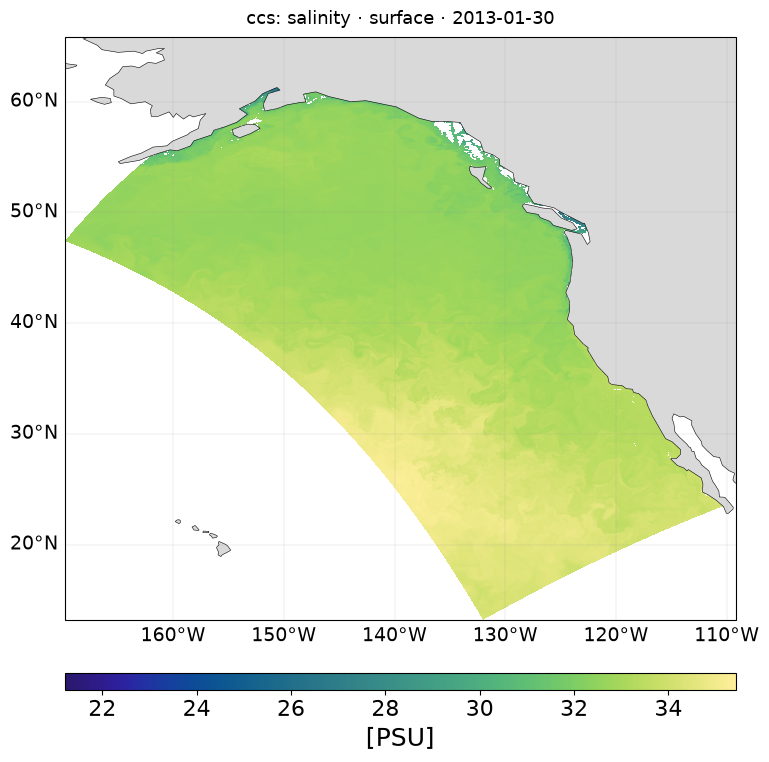

In [9]:
osk.field(
    model2, "salinity",
    select={"depth": "surface", "time": '2013-01-30T00:00:00'},
).plot()

<div class="alert alert-block alert-info">
    <b>Note:</b> Any plot or animation can be rendered in an interactive manner with `hvplot` and `holoviews` instead of static with `matplotlib`. Do this by including `renderer="holoviews"` in the `plot()` command.
</div>


In [ ]:
osk.field(
    model2, "salinity",
    select={"depth": "surface", "time": '2013-01-30T00:00:00'},
).plot(renderer="holoviews", zoom=2)

### Surface Alkalinity Monthly Means

/tmp/ipykernel_304720/2816259875.py:1: UserWarning: 'alkalinity' resolved to standard_name 'sea_water_alkalinity_expressed_as_mole_equivalent' (Field variable=)
  osk.field(


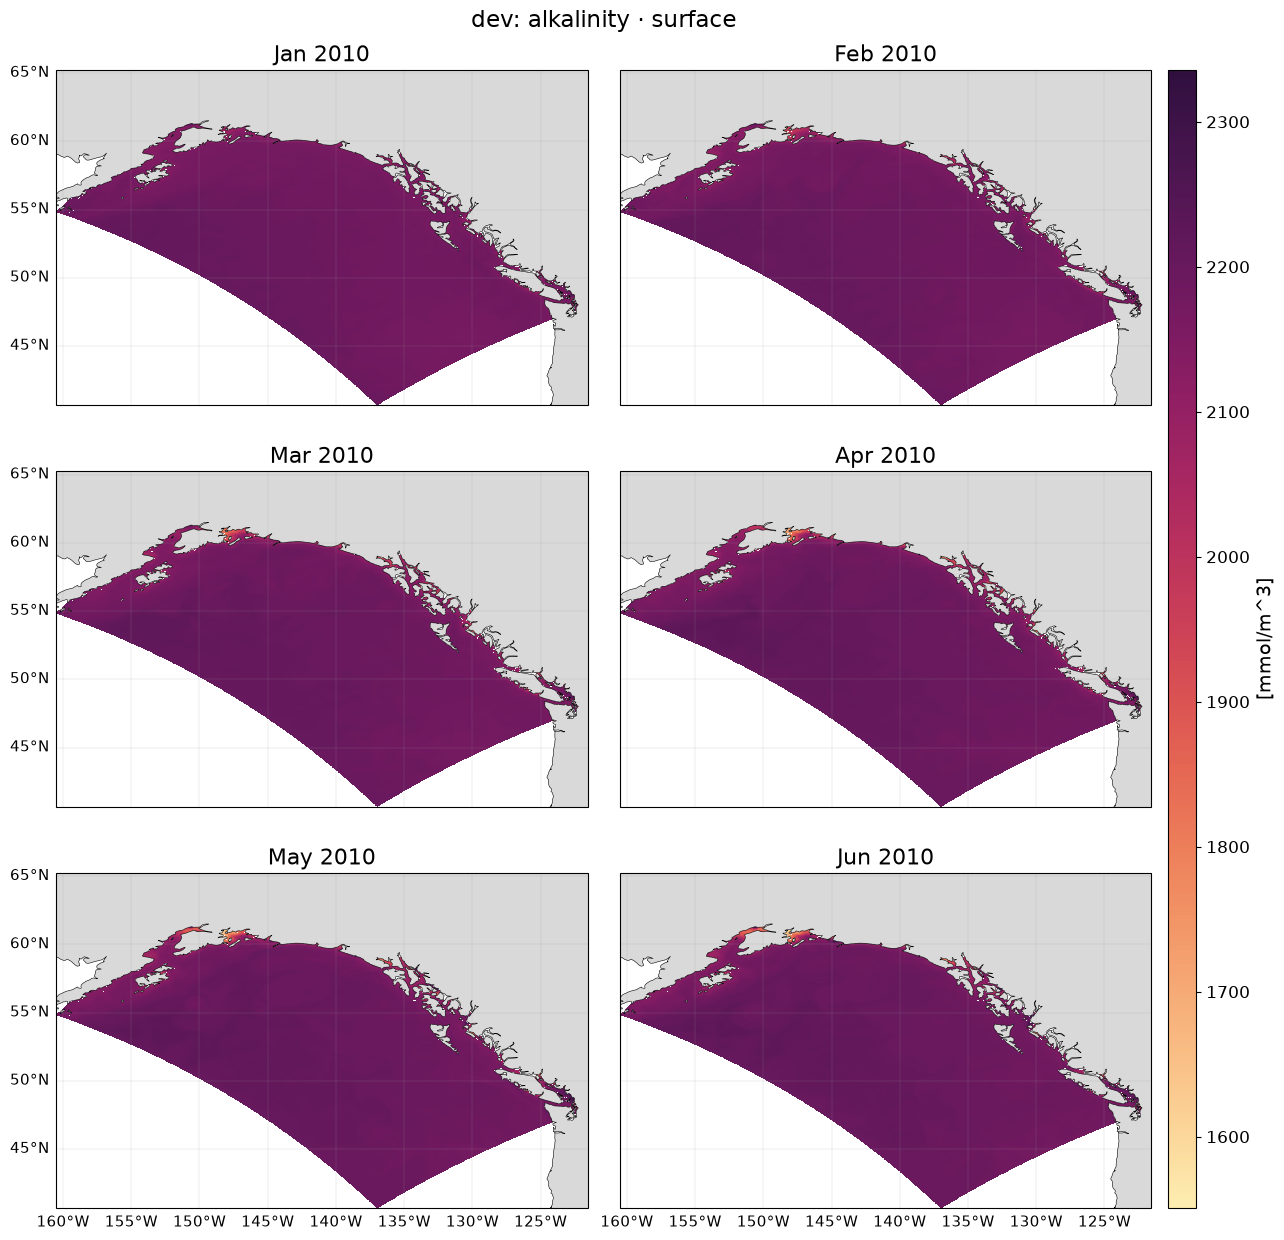

In [83]:
osk.field(
    model1a, "alkalinity",
    select={"depth": "surface"},
    aggregate={"time": {"resample": "1MS", "reduce": "mean"}},
).plot(zoom=1.5)

### Monthly means at multiple depths

/tmp/ipykernel_304720/851035291.py:1: UserWarning: 'iron' resolved to standard_name 'mole_concentration_of_dissolved_iron_in_sea_water' (Field variable=)
  osk.field(


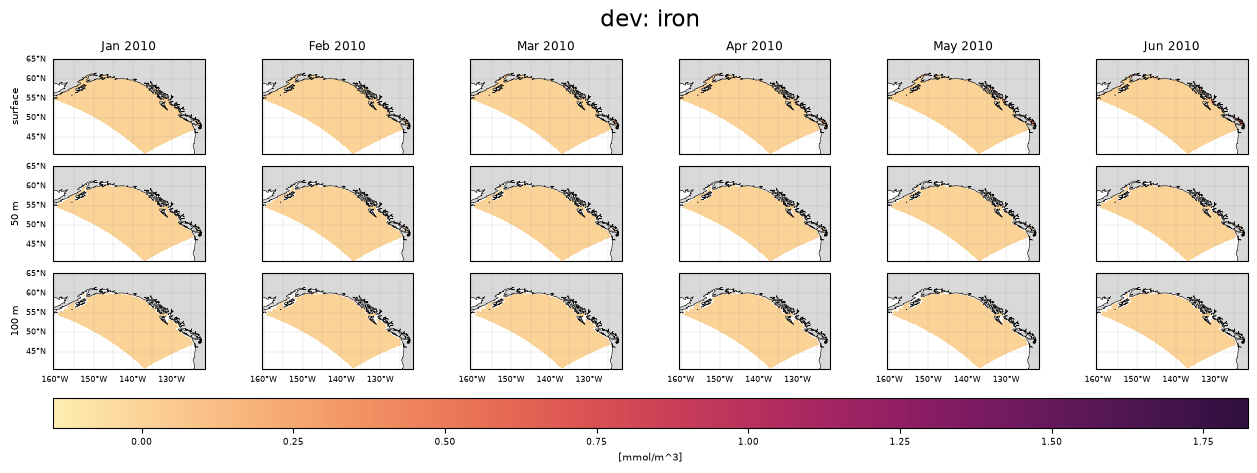

In [84]:
osk.field(
    model1a, "iron",
    select={"depth": ["surface", 50, 100]},
    aggregate={"time": {"resample": "1MS", "reduce": "mean"}},
).plot(zoom=1.5, shared_limits=True,)

### Extremum at one time

/tmp/ipykernel_304720/4208765265.py:1: UserWarning: 'temperature' resolved to standard_name 'sea_water_potential_temperature' (Field variable=)
  run = osk.field(model1a, "temperature",
/tmp/ipykernel_304720/4208765265.py:3: UserWarning: 'dev': select key(s) ['method'] matched no axis before or after aggregate={} ran; the standing axes are ['eta_rho', 'xi_rho']. If one of these names an axis the aggregate creates -- a groupby renames its dim to the grouping key, e.g. time -> month -- check the spelling against what the aggregate actually produced. Otherwise this is the ordinary case of a select shared across variables that don't all carry the same axis, and can be ignored.
  ext = run.extremum("max")   # human-readable: value, lon/lat (+convention),
/tmp/ipykernel_304720/4208765265.py:5: UserWarning: 'dev': select key(s) ['method'] matched no axis before or after aggregate={} ran; the standing axes are ['time']. If one of these names an axis the aggregate creates -- a groupby renames i

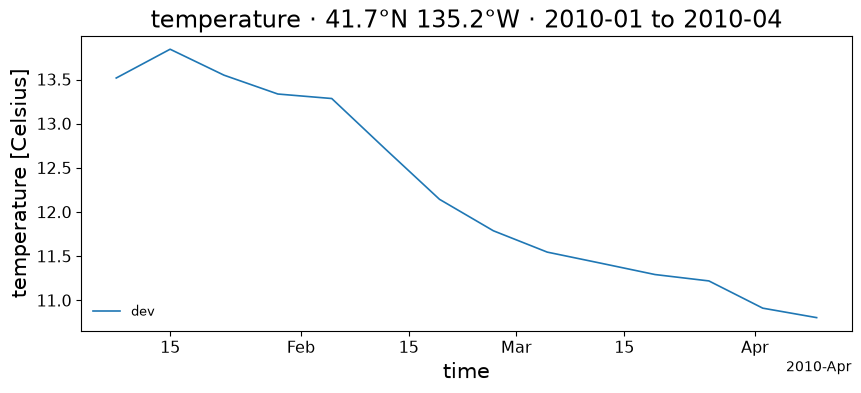

In [85]:
run = osk.field(model1a, "temperature",
                select={"depth": "surface", "time": '2010-01-26', "method": "nearest"})
ext = run.extremum("max")   # human-readable: value, lon/lat (+convention),
                            # grid indices {eta_rho: 112, xi_rho: 387}, time, depth
ext.series().plot()         # time series at that cell, ±10 native steps around the snapshot


### Time Series

/tmp/ipykernel_304720/3948003426.py:3: UserWarning: 'temperature' resolved to standard_name 'sea_water_potential_temperature' (Field variable=)
  run = osk.field(
/tmp/ipykernel_304720/3948003426.py:3: UserWarning: 'salinity' resolved to standard_name 'sea_water_practical_salinity' (Field variable=)
  run = osk.field(


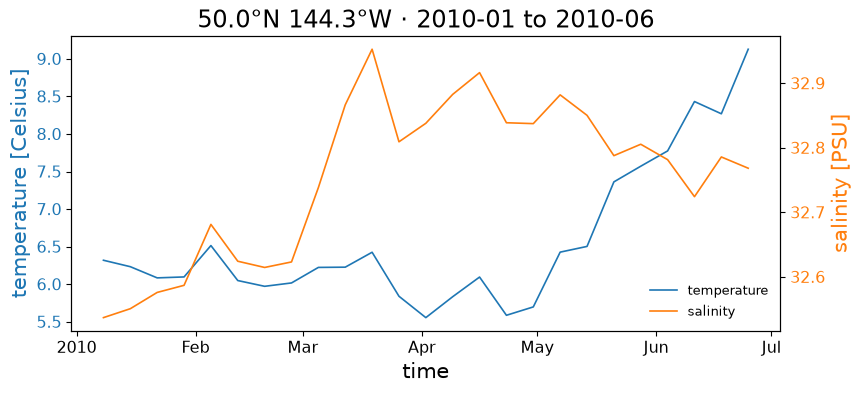

In [86]:
import ocean_skill as osk

run = osk.field(
    model1a, ["temperature","salinity"],
    select={"lon": -144.25, "lat": 50.0, "depth": "surface"},#, "time": slice("2010-01", "2012-12")},
)
run.plot()                       # one solid line
# run.plot(renderer="holoviews")   # same line, interactive with hover

/tmp/ipykernel_304720/3644114057.py:3: UserWarning: 'temperature' resolved to standard_name 'sea_water_potential_temperature' (Field variable=)
  run = osk.field(
/tmp/ipykernel_304720/3644114057.py:3: UserWarning: 'salinity' resolved to standard_name 'sea_water_practical_salinity' (Field variable=)
  run = osk.field(
/tmp/ipykernel_304720/3644114057.py:3: UserWarning: 'alkalinity' resolved to standard_name 'sea_water_alkalinity_expressed_as_mole_equivalent' (Field variable=)
  run = osk.field(


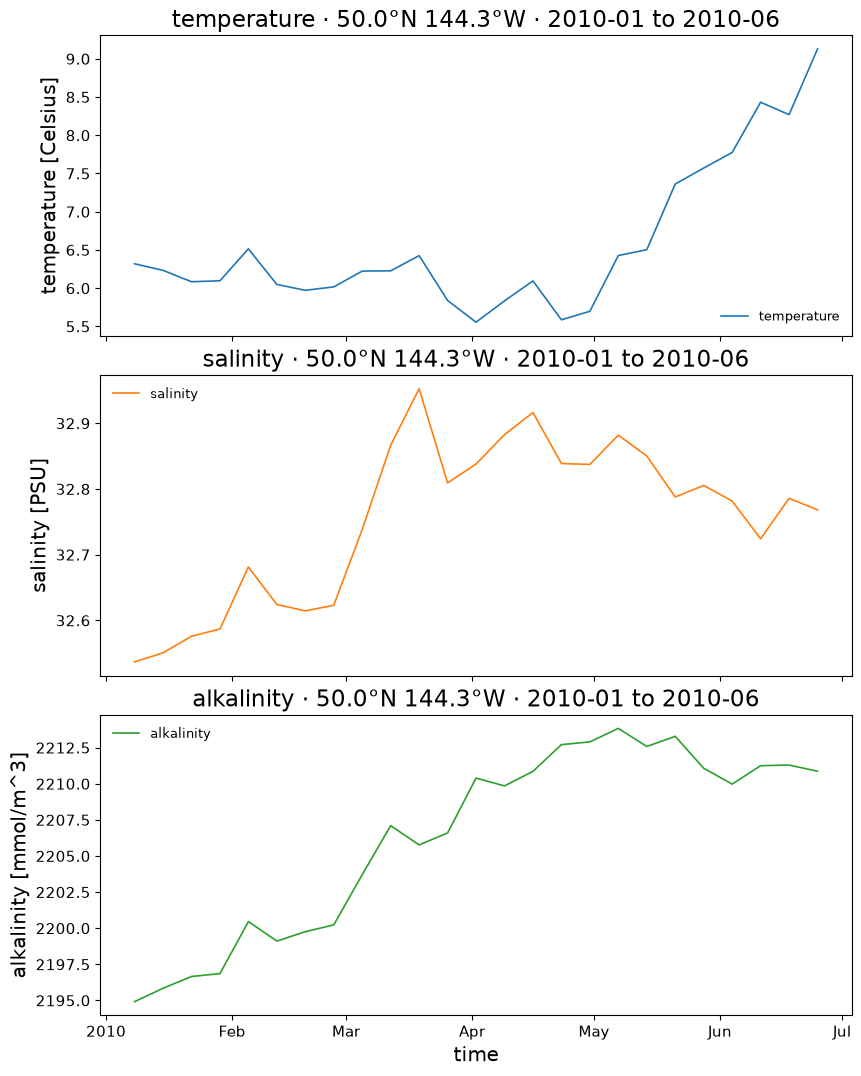

In [15]:
import ocean_skill as osk

run = osk.field(
    model1a, ["temperature","salinity","alkalinity"],
    select={"lon": -144.25, "lat": 50.0, "depth": "surface"},#, "time": slice("2010-01", "2012-12")},
)
run.plot()                       # one solid line
# run.plot(renderer="holoviews")   # same line, interactive with hover

### Movie

In [ ]:
%%time

run = osk.field(model1a, "mole_concentration_of_ammonium_in_sea_water",
                select={"depth": "surface"},)

# run.plot()                     # every step as a panel
# run.movie(save="salt.mp4")        # every step as a frame
run.movie(renderer="holoviews")   # every step on a slider


In [ ]:
%%time

run = osk.field(model2, "temperature",
                select={"depth": "surface"},)

# run.plot()                     # every step as a panel
# run.movie(save="salt.mp4")        # every step as a frame
run.movie(renderer="holoviews")   # every step on a slider


In [18]:
run = osk.field(model2cdr, "CO3",
                select={"depth": "surface"},)

# run.plot()                     # every step as a panel
run.movie(save="CO3.gif")        # every step as a frame
# run.movie(renderer="holoviews")   # every step on a slider


  frame 17/17
ocean-skill: movie written to CO3.gif


## Compare Two Models

### Several Variables at One Time

  comparing nitrate 'dev_marblsub' vs 'dev' [1/1]


/tmp/ipykernel_304720/1814418804.py:1: UserWarning: 'nitrate' resolved to standard_name 'mole_concentration_of_nitrate_in_sea_water' (compare variables=)
  multi_vars = osk.compare(
/tmp/ipykernel_304720/1814418804.py:1: UserWarning: 'phosphate' resolved to standard_name 'mole_concentration_of_phosphate_in_sea_water' (compare variables=)
  multi_vars = osk.compare(
/tmp/ipykernel_304720/1814418804.py:1: UserWarning: 'silicate' resolved to standard_name 'mole_concentration_of_silicate_in_sea_water' (compare variables=)
  multi_vars = osk.compare(
/tmp/ipykernel_304720/1814418804.py:1: UserWarning: 'oxygen' resolved to standard_name 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water' (compare variables=)
  multi_vars = osk.compare(


  comparing phosphate 'dev_marblsub' vs 'dev' [1/1]
  comparing silicate 'dev_marblsub' vs 'dev' [1/1]
  comparing oxygen 'dev_marblsub' vs 'dev' [1/1]
  4 comparison(s) formed; 0 skipped


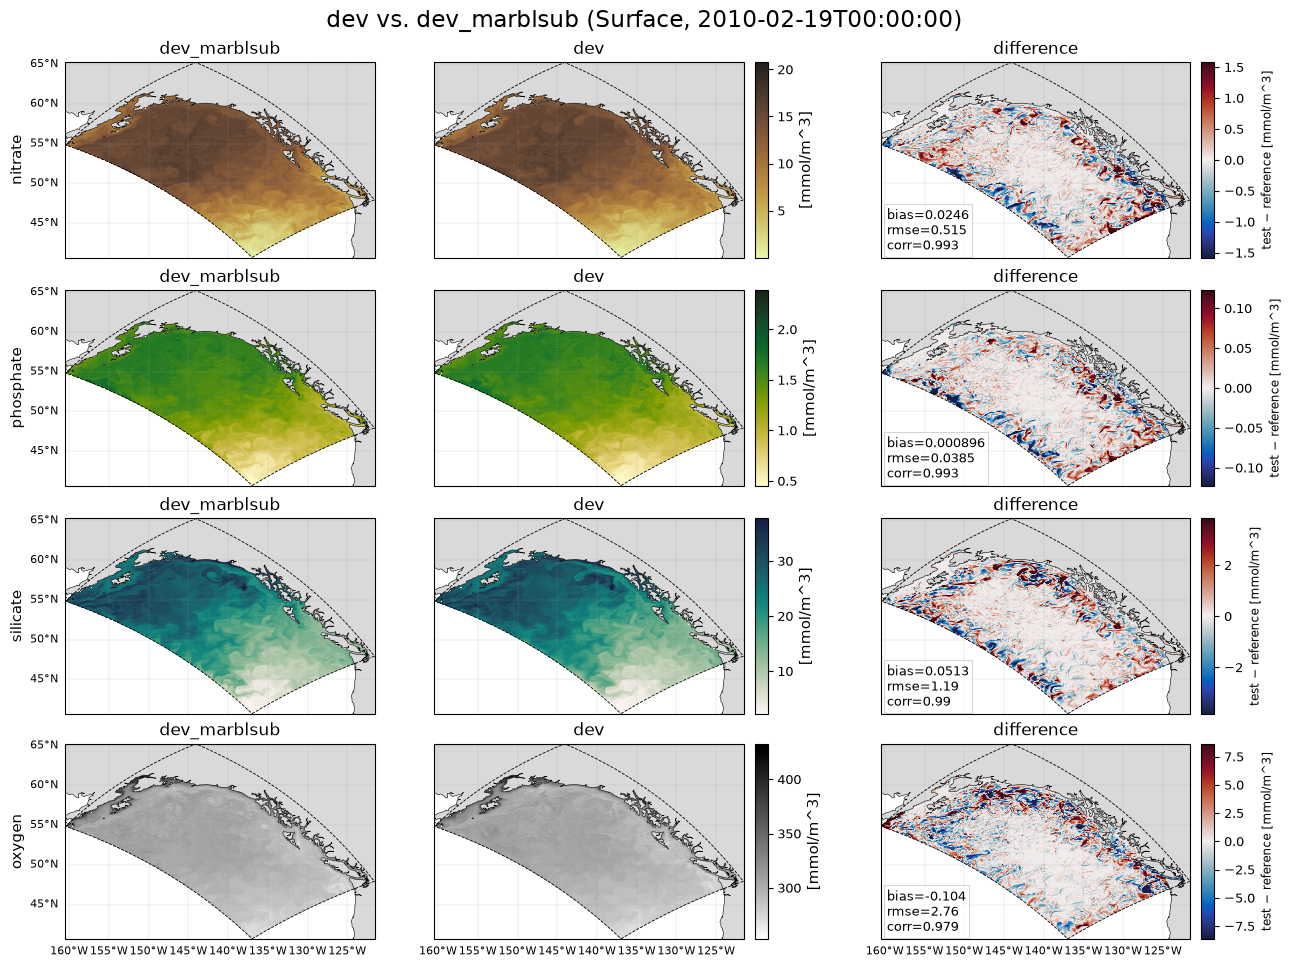

In [19]:
multi_vars = osk.compare(
    reference=model1a,
    test=model1b,
    variables=["nitrate", "phosphate", "silicate", "oxygen"],
    depths=["surface"],
    select={"T": '2010-02-19T00:00:00'},
)
multi_vars.plot(title=f"dev vs. dev_marblsub (Surface, 2010-02-19T00:00:00)", zoom=1.5)

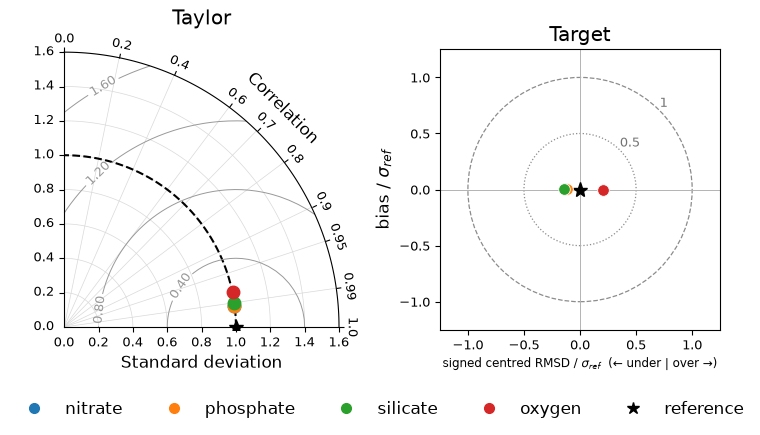

In [20]:
multi_vars.summary()

### Calculate metrics between models

/tmp/ipykernel_304720/2093585826.py:1: UserWarning: 'silicate' resolved to standard_name 'mole_concentration_of_silicate_in_sea_water' (compare variables=)
  metrics = osk.compare(


  comparing 'dev_marblsub' vs 'dev' [1/1]
  1 comparison(s) formed; 0 skipped


/home/kthyng/miniforge3/envs/ocean-skill/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/kthyng/miniforge3/envs/ocean-skill/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/plot/matplotlib_renderer.py:6560: UserWarning: the maps are only 5.48in wide: 4 rows are sharing a canvas capped at 16.5in, and the type is already at its 6pt floor, so there is no room left to reclaim. Rather than shrinking the text, lift the height cap (size="free") or draw fewer rows per figure.
  return skill_map(spec.items, **opts)


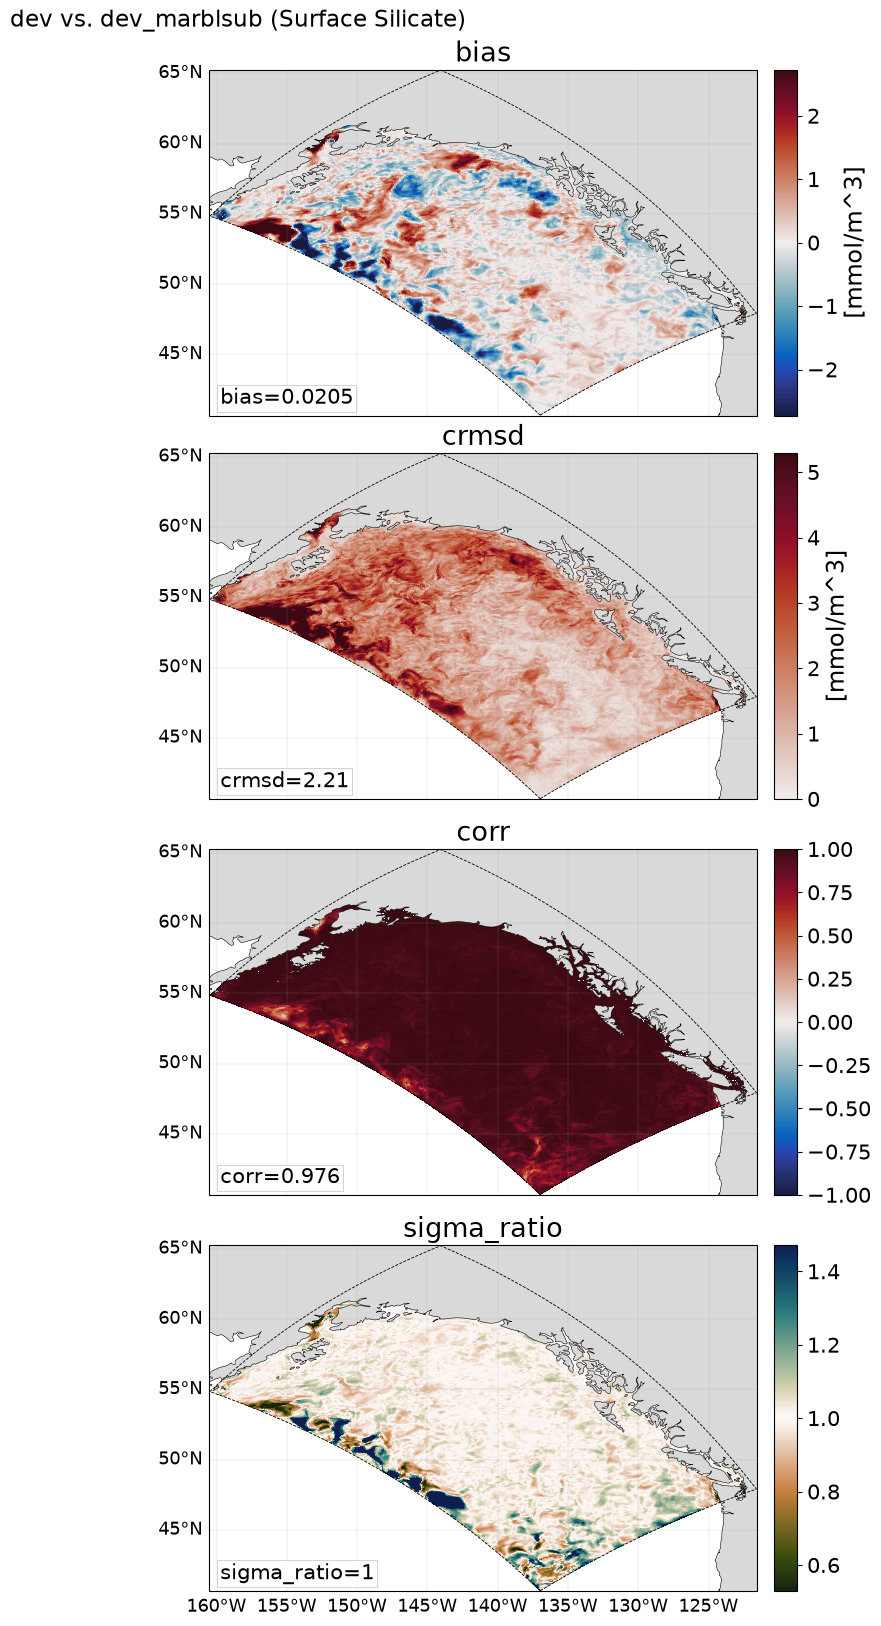

In [87]:
metrics = osk.compare(
    reference=model1a,
    test=model1b,
    variables=["silicate"],
    depths=["surface"],
    over="time",
)
metrics.plot(title=f"dev vs. dev_marblsub (Surface Silicate)", zoom=1.5)

### One Variable Monthly Means

  comparing 'dev_marblsub' vs 'dev' [1/1]


/tmp/ipykernel_304720/559179781.py:1: UserWarning: 'silicate' resolved to standard_name 'mole_concentration_of_silicate_in_sea_water' (compare variables=)
  monthly_means = osk.compare(


  6 comparison(s) formed; 0 skipped


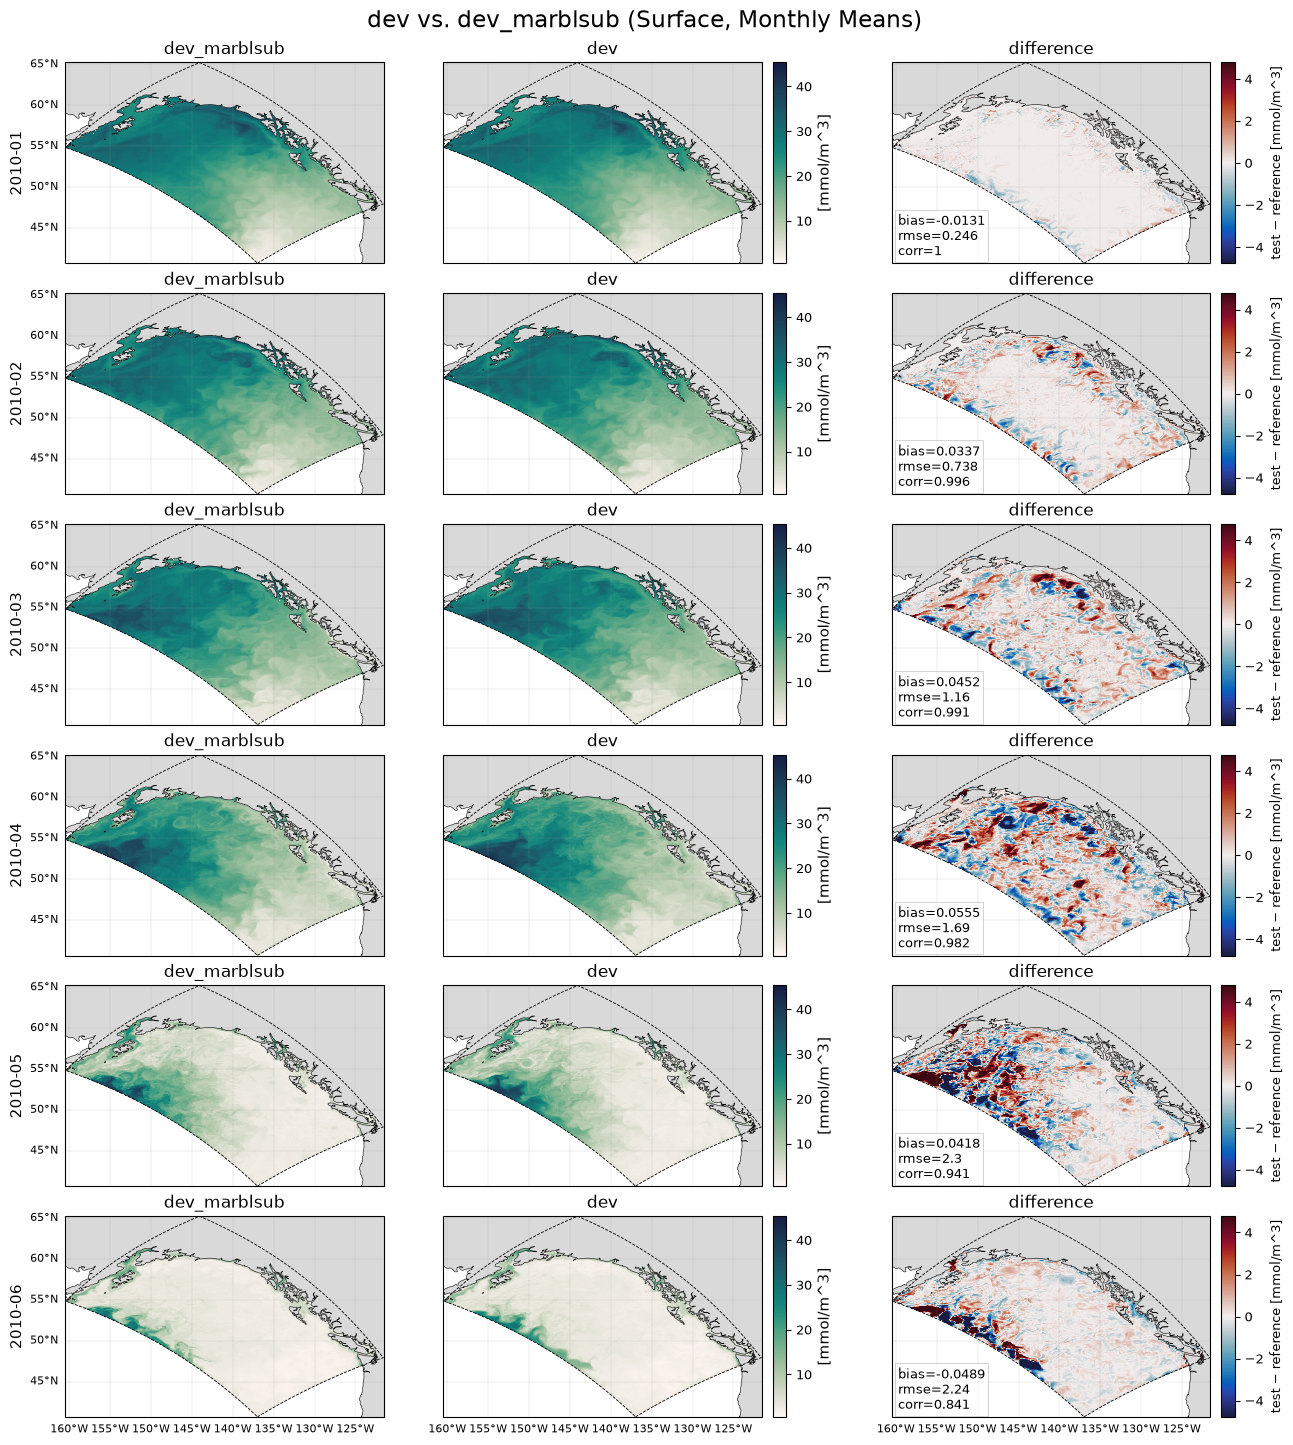

In [22]:
monthly_means = osk.compare(
    reference=model1a, test=model1b,
    variables=["silicate"], depths=["surface"],
    times={"resample": "1MS", "reduce": "mean"},
)
monthly_means.plot(title="dev vs. dev_marblsub (Surface, Monthly Means)", zoom=1.5, shared_limits=True)

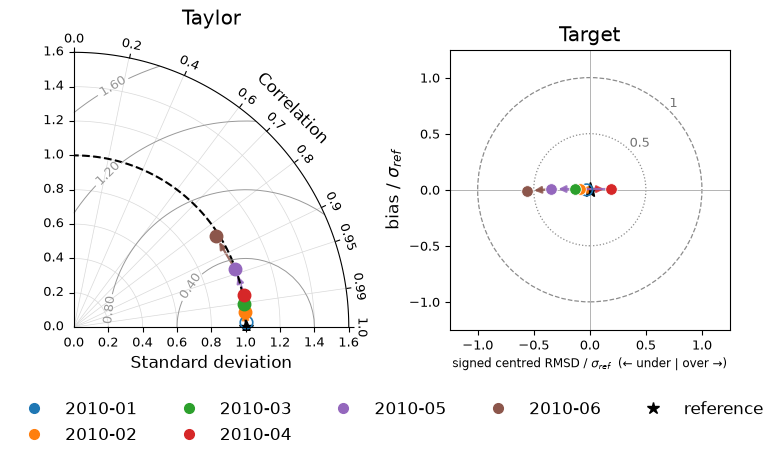

In [23]:
monthly_means.summary(arrows=True)

### Time Series

/tmp/ipykernel_304720/3719885273.py:1: UserWarning: 'temperature' resolved to standard_name 'sea_water_potential_temperature' (compare variables=)
  point = osk.compare(
/tmp/ipykernel_304720/3719885273.py:1: UserWarning: 'salinity' resolved to standard_name 'sea_water_practical_salinity' (compare variables=)
  point = osk.compare(
/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/comparison.py:5404: UserWarning: only 25 time steps: metrics are weakly constrained. Usually the two records overlap over only a short period, or the binning left few of them — see the aligned pair's attrs for what matched.
  self._metrics = _metrics.compute(


  comparing temperature 'dev_marblsub' vs 'dev' [1/1]
  comparing salinity 'dev_marblsub' vs 'dev' [1/1]
  2 comparison(s) formed; 0 skipped


/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/comparison.py:5404: UserWarning: only 25 time steps: metrics are weakly constrained. Usually the two records overlap over only a short period, or the binning left few of them — see the aligned pair's attrs for what matched.
  self._metrics = _metrics.compute(


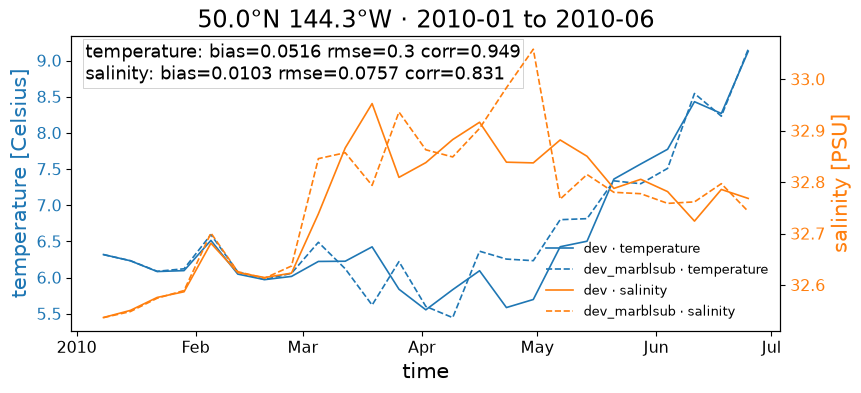

In [24]:
point = osk.compare(
    reference=model1a, test=model1b, variables=["temperature","salinity"],
    select={"lon": -144.25, "lat": 50.0}
)
point.plot()

### Summary Plots


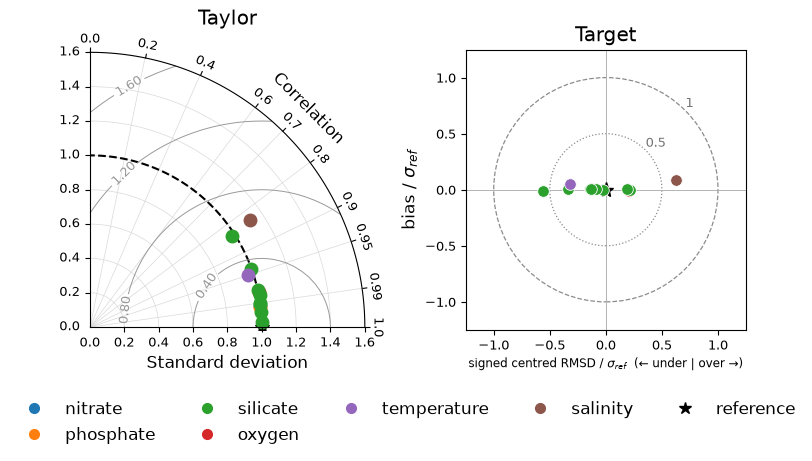

In [92]:
osk.summary([multi_vars, metrics, monthly_means, point], color_by="variable")            

## Data catalogs

### `featureTypes`

All data sources are explicitly or implicitly guessed with their `featureType`. Once known, this gives `ocean-skill` necessary basic information about what sorts of calculations are possible with the data source. The code will guess if this is not provided when a catalog is created. Some we might encounter:

| `featureType`      | Example data type      | Currently available and used in `ocean-skill`? |
|---------------------|-------------------------|----------------------------------------|
| `profile`           | CTD profile             | Yes.                                    |
| `timeSeries`        | Station buoy             | Yes.                                    |
| `timeSeriesProfile` | Repeat CTD profiles      | Yes.                                    |
| `trajectoryProfile` | Drifters                 | No.                                     |
| `grid`              | Sat data, WOA, GLODAP    | Yes. Not technically in CF definitions.        |

See more information on [feature types](https://cfconventions.org/cf-conventions/cf-conventions.html#discrete-sampling-geometries).

#### profile

In [26]:

cat_name_ctd = "argo_demo"
if cat_name_ctd not in osk.find_catalogs():

    cat = new_catalog(title="Argo CTD demo")
    add_erddap_source(
        cat,
        "argo_4900453_c199",
        server="https://erddap.ifremer.fr/erddap",
        dataset_id="ArgoFloats",
        featureType="profile",                        # fixed lon/lat + pressure axis
        variables=["platform_number", "cycle_number", "time",
                   "longitude", "latitude", "pres", "temp", "psal"],
        mask_failed_qartod=False,                      # Argo has no OOI-style aggregate flags
        reader_kwargs={"constraints": {"platform_number=": "4900453",
                                       "cycle_number=": 199}},
    )
    save(cat, f"{shared_cat_path}/{cat_name_ctd}.yaml")

else:
    print(f"Catalog {cat_name_ctd} already exists!\n")

Catalog argo_demo already exists!



In [27]:
osk.describe("argo_4900453_c199")

source: argo_demo:argo_4900453_c199
  path: /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/argo_demo.yaml
  axes: {'T': 'time (UTC)', 'X': 'longitude (degrees_east)', 'Y': 'latitude (degrees_north)', 'Z': 'pres (decibar)'}
  dataset_id: ArgoFloats
  featureType: profile
  featureType_source: inferred
  geospatial_lat_max: 57.14899826049805
  geospatial_lat_min: 57.14899826049805
  geospatial_lon_max: -145.48899841308594
  geospatial_lon_min: -145.48899841308594
  geospatial_vertical_max: 1985.1
  geospatial_vertical_min: 4.4
  lon_convention: -180-180
  server: https://erddap.ifremer.fr/erddap
  standard_names: {'cycle_number': 'cycle_number', 'platform_number': 'platform_number', 'psal (PSU)': 'psal', 'temp (degree_Celsius)': 'temp'}
  time_coverage_end: 2010-01-16
  time_coverage_start: 2010-01-16
  units: {'psal (PSU)': 'PSU', 'temp (degree_Celsius)': 'degree_Celsius'}
  variables: ['cycle_number', 'platform_number', 'psal', 'temp']
  vocabulary:
    matched (2):
      salinity     <- psal
      temperature  <- temp
    unmatched (2):
      cycle_number, platform_number
  coordinates:
    matched (4):
      T (time)       <- time (UTC)
      X (longitude)  <- longitude (degrees_east)
      Y (latitude)   <- latitude (degrees_north)
      Z (vertical)   <- pres (decibar)
    missing (0)

/tmp/ipykernel_304720/2023583088.py:1: UserWarning: 'salt' resolved to standard_name 'sea_water_practical_salinity' (Field variable=)
  osk.field("argo_4900453_c199", ["salt","temp"]).plot(zoom=0.4)
/tmp/ipykernel_304720/2023583088.py:1: UserWarning: 'temp' resolved to standard_name 'sea_water_potential_temperature' (Field variable=)
  osk.field("argo_4900453_c199", ["salt","temp"]).plot(zoom=0.4)


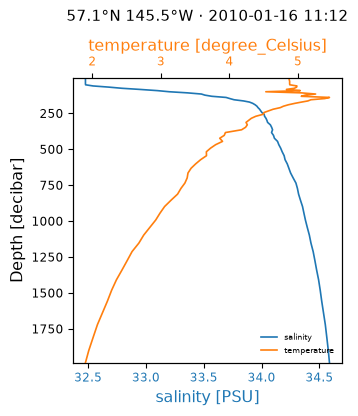

In [28]:
osk.field("argo_4900453_c199", ["salt","temp"]).plot(zoom=0.4)

#### timeSeries

Make catalog with example for both timeSeries and timeSeriesProfile

In [29]:
SERVER = "https://data.pmel.noaa.gov/pmel/erddap"
WINDOW = {"time>=": "2010-01-08T00:00:00Z", "time<=": "2010-06-25T23:59:59Z"}  # dev range

def add_papa_profile(name, dataset_id, obs_col, new_name):
    r = add_erddap_source(
        cat, name,
        server=SERVER, dataset_id=dataset_id,
        featureType="timeSeriesProfile",              # time + depth both vary
        variables=["time", "latitude", "longitude", "depth", obs_col, f"{obs_col}_QC"],
        mask_failed_qartod=False,                     # osk auto-detects the *_QC companion
        reader_kwargs={"constraints": WINDOW},
        # note: NO nominal_depth_m -- the `depth` column supplies the vertical axis
    )
    # rename obs_col -> new_name via the standard_names map (optional: TEMP/PSAL already resolve)
    sn = r.metadata.get("standard_names", {})         # {"TEMP (degree_Celsius)": "TEMP", ...}
    rename = {obs_col: new_name}
    r.metadata["standard_names"] = {c: rename.get(b, b) for c, b in sn.items()}
    r.metadata["variables"] = sorted(set(r.metadata["standard_names"].values()))
    return r

cat_name_timeseries = "papa_timeseries"
if cat_name_timeseries not in osk.find_catalogs():

    cat = new_catalog(title="Station Papa surface mooring")
    
    r = add_erddap_source(
        cat, "papa_co2",
        server=SERVER,
        dataset_id="pmel_co2_moorings_cba8_5413_09f9",
        featureType="timeSeries",                     # no depth axis -> single-level series
        variables=["time", "latitude", "longitude", "SST", "SSS", "pCO2_sw", "pH_sw", "DOXY", "CHL"],
        nominal_depth_m=0.0,                         # <-- depth taken as the surface
        mask_failed_qartod=False,
        reader_kwargs={"constraints": {"time>=": "2010-01-01T00:00:00Z",
                                       "time<=": "2011-01-01T23:59:59Z"}},
    )

    # Rename columns -> names osk resolves (values become the CF concept it matches on)
    RENAME = {
        "SST":     "temp",           # sea_water_potential_temperature  (dev: temp)
        "SSS":     "salinity",       # sea_water_practical_salinity      (dev: salt)
        "DOXY":    "oxygen",         # ...dissolved_molecular_oxygen     (dev: O2)
        "pH_sw":   "pH",             # sea_water_ph_reported_on_total_scale (dev: MARBL_PH_SURF)
        "CHL":     "chlorophyll",
        "pCO2_sw": "surface_partial_pressure_of_carbon_dioxide_in_sea_water",  # no dev counterpart
    }
    sn = r.metadata.get("standard_names", {})        # {"SST (deg C)": "SST", ...} from the probe
    r.metadata["standard_names"] = {col: RENAME.get(base, base) for col, base in sn.items()}
    r.metadata["variables"] = sorted(set(r.metadata["standard_names"].values()))


    
    add_papa_profile("papa_temp", "papa_hourly_temp", "TEMP", "temp")       # -> matches dev `temp`
    add_papa_profile("papa_psal", "papa_hourly_psal", "PSAL", "salinity")   # -> matches dev `salt`
    
    save(cat, f"{shared_cat_path}/{cat_name_timeseries}.yaml")

else:
    print(f"Catalog {cat_name_timeseries} already exists!\n")


Catalog papa_timeseries already exists!



In [30]:
osk.describe("papa_co2")

source: papa_timeseries:papa_co2
  path: /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/papa_timeseries.yaml
  axes: {'T': 'time (UTC)', 'X': 'longitude (degrees_east)', 'Y': 'latitude (degrees_north)'}
  dataset_id: pmel_co2_moorings_cba8_5413_09f9
  featureType: timeSeries
  featureType_source: inferred
  geospatial_lat_max: 50.13
  geospatial_lat_min: 50.13
  geospatial_lon_max: -144.84
  geospatial_lon_min: -144.84
  lon_convention: -180-180
  nominal_depth_m: 0.0
  server: https://data.pmel.noaa.gov/pmel/erddap
  standard_names: {'CHL (ug/l)': 'chlorophyll', 'DOXY (PSU)': 'oxygen', 'SSS (PSU)': 'salinity', 'SST (deg C)': 'temp', 'pCO2_sw (uatm)': 'surface_partial_pressure_of_carbon_dioxide_in_sea_water', 'pH_sw': 'pH'}
  time_coverage_end: 2011-01-01
  time_coverage_start: 2010-01-01
  units: {'CHL (ug/l)': 'ug/l', 'DOXY (PSU)': 'PSU', 'SSS (PSU)': 'PSU', 'SST (deg C)': 'deg C', 'pCO2_sw (uatm)': 'uatm'}
  variables: ['chlorophyll', 'oxygen', 'pH', 'salinity', 'surface_partial_pressure_of_carbon_dioxide_in_sea_water', 'temp']
  vocabulary:
    matched (5):
      chlorophyll  <- chlorophyll
      oxygen       <- oxygen
      ph           <- pH
      salinity     <- salinity
      temperature  <- temp
    unmatched (1):
      surface_partial_pressure_of_carbon_dioxide_in_sea_water
  coordinates:
    matched (3):
      T (time)       <- time (UTC)
      X (longitude)  <- longitude (degrees_east)
      Y (latitude)   <- latitude (degrees_north)
    missing (1): Z

/tmp/ipykernel_304720/2813374562.py:1: UserWarning: 'salt' resolved to standard_name 'sea_water_practical_salinity' (Field variable=)
  osk.field("papa_co2", ["salt","temp", "chlorophyll", "ph"]).plot()
/tmp/ipykernel_304720/2813374562.py:1: UserWarning: 'temp' resolved to standard_name 'sea_water_potential_temperature' (Field variable=)
  osk.field("papa_co2", ["salt","temp", "chlorophyll", "ph"]).plot()
/tmp/ipykernel_304720/2813374562.py:1: UserWarning: 'chlorophyll' resolved to standard_name 'mass_concentration_of_chlorophyll_a_in_sea_water' (Field variable=)
  osk.field("papa_co2", ["salt","temp", "chlorophyll", "ph"]).plot()
/tmp/ipykernel_304720/2813374562.py:1: UserWarning: 'ph' resolved to standard_name 'sea_water_ph_reported_on_total_scale' (Field variable=)
  osk.field("papa_co2", ["salt","temp", "chlorophyll", "ph"]).plot()


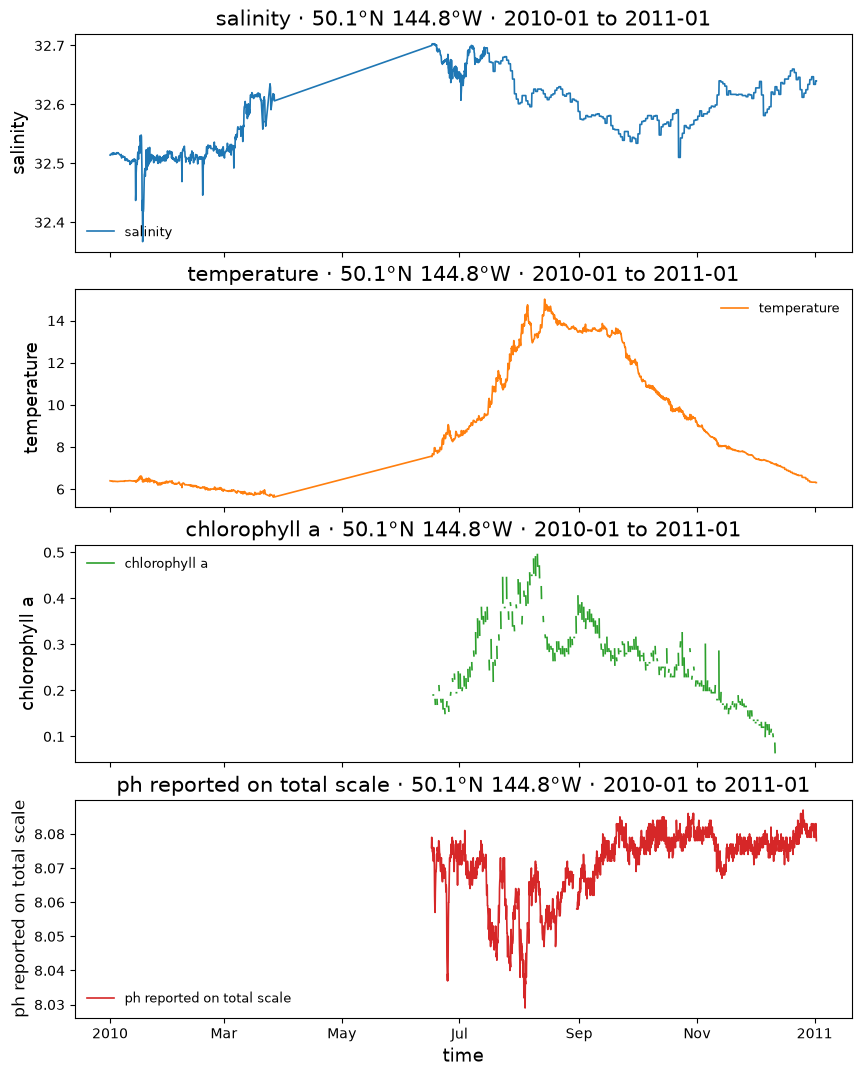

In [31]:
osk.field("papa_co2", ["salt","temp", "chlorophyll", "ph"]).plot()

#### timeSeriesProfile

/tmp/ipykernel_304720/1015771350.py:1: UserWarning: 'temp' resolved to standard_name 'sea_water_potential_temperature' (Field variable=)
  osk.field("papa_temp", "temp").plot()


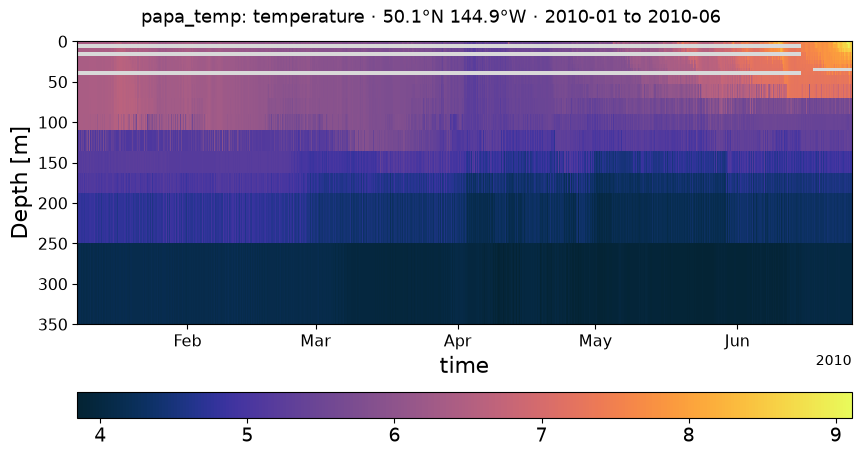

In [32]:
osk.field("papa_temp", "temp").plot()

#### grid

In [33]:

# Same name_map GLODAP's shipped catalog uses, so standard_names/variables come out
# identical to the internet-backed entry (GLODAP's raw files carry no standard_name
# attrs of their own).
GLODAP_NAME_MAP = {
    "NO3": "mole_concentration_of_nitrate_in_sea_water",
    "PO4": "mole_concentration_of_phosphate_in_sea_water",
    "TAlk": "sea_water_alkalinity_expressed_as_mole_equivalent",
    "TCO2": "mole_concentration_of_dissolved_inorganic_carbon_in_sea_water",
    "oxygen": "mole_concentration_of_dissolved_molecular_oxygen_in_sea_water",
    "salinity": "sea_water_practical_salinity",
    "silicate": "mole_concentration_of_silicate_in_sea_water",
    "temperature": "sea_water_potential_temperature",
}

SHARED = "/mnt/cooltub/cw/cstar-forge-data/source-data/catalogs"  # a dir on $OCEAN_SKILL_CATALOGS

build_catalog(
    {
        "glodap": {
            "reader": "ocean_skill.readers:PoochTarNetCDF",
            "reader_kwargs": {
                # same reader as the internet entry, just local_dir instead of url
                "local_dir": "/mnt/cooltub/cw/cstar-forge-data/"
                "source-data/GLODAP",
                "member_glob": "*.nc",
                "var_from_filename": True,
                "keep_vars": ["Depth"],
            },
            "name_map": GLODAP_NAME_MAP,
            # carried over from the shipped catalog so osk.find()/osk.describe() see
            # the same descriptive metadata either way
            "institution": "NOAA NCEI / GLODAPv2",
            "climatology": True,
            "depth_coord": "depth_surface",
            "nominal_resolution_km": 111,
            "notes": "Open-ocean product: marginal seas are largely masked (~8% "
            "coverage in the Gulf of Mexico).",
            "references": "Olsen et al. 2016 (ESSD); Lauvset et al. GLODAPv2.2016b",
        }
    },
    f"{SHARED}/glodap.yaml",
    title="GLODAPv2.2016b Mapped Climatology",
)

ocean-skill: glodap.yaml — 8 variables across 1 sources: 8 matched, 0 unmatched


PosixPath('/mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/glodap.yaml')

In [34]:
%%time

cat_name_woa = "woa"

# tanagra version
# WOA23 — local copies on tanagra, same shared reader options
if host == "tanagra":
    LOCAL = "/mnt/cooltub/cw/cstar-forge-data/source-data/WOA"

CODE = {"nitrate": "n", "phosphate": "p", "silicate": "i", "oxygen": "o"}
build_catalog(
    {f"woa23_{var}_month{m:02d}": f"{LOCAL}/woa23_all_{c}{m:02d}_01.nc"
     for var, c in CODE.items() for m in range(1, 13)},
    f"{shared_cat_path}/{cat_name_woa}.yaml", title="WOA23",
    reader_kwargs={"decode_times": False, "engine": "h5netcdf", "chunks": {}},
)


ocean-skill: woa.yaml — 4 variables across 48 sources: 4 matched, 0 unmatched
CPU times: user 4.17 s, sys: 47.3 ms, total: 4.22 s
Wall time: 4.37 s


PosixPath('/mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/woa.yaml')

In [35]:
osk.describe("woa")

catalog: woa
  description: WOA23 objectively-analyzed climatology; files cached on first read.
  featureTypes: ['grid']
  institution: NOAA NCEI
  title: World Ocean Atlas 2023 (1 deg) — annual + monthly climatology
  sources (78): woa23_nitrate_annual, woa23_nitrate_month01, woa23_nitrate_month02, woa23_nitrate_month03, woa23_nitrate_month04, woa23_nitrate_month05, woa23_nitrate_month06, woa23_nitrate_month07, woa23_nitrate_month08, woa23_nitrate_month09, woa23_nitrate_month10, woa23_nitrate_month11, woa23_nitrate_month12, woa23_oxygen_annual, woa23_oxygen_month01, woa23_oxygen_month02, woa23_oxygen_month03, woa23_oxygen_month04, woa23_oxygen_month05, woa23_oxygen_month06, woa23_oxygen_month07, woa23_oxygen_month08, woa23_oxygen_month09, woa23_oxygen_month10, woa23_oxygen_month11, woa23_oxygen_month12, woa23_phosphate_annual, woa23_phosphate_month01, woa23_phosphate_month02, woa23_phosphate_month03, woa23_phosphate_month04, woa23_phosphate_month05, woa23_phosphate_month06, woa23_phosphate_month07, woa23_phosphate_month08, woa23_phosphate_month09, woa23_phosphate_month10, woa23_phosphate_month11, woa23_phosphate_month12, woa23_salinity_annual, woa23_salinity_month01, woa23_salinity_month02, woa23_salinity_month03, woa23_salinity_month04, woa23_salinity_month05, woa23_salinity_month06, woa23_salinity_month07, woa23_salinity_month08, woa23_salinity_month09, woa23_salinity_month10, woa23_salinity_month11, woa23_salinity_month12, woa23_silicate_annual, woa23_silicate_month01, woa23_silicate_month02, woa23_silicate_month03, woa23_silicate_month04, woa23_silicate_month05, woa23_silicate_month06, woa23_silicate_month07, woa23_silicate_month08, woa23_silicate_month09, woa23_silicate_month10, woa23_silicate_month11, woa23_silicate_month12, woa23_temperature_annual, woa23_temperature_month01, woa23_temperature_month02, woa23_temperature_month03, woa23_temperature_month04, woa23_temperature_month05, woa23_temperature_month06, woa23_temperature_month07, woa23_temperature_month08, woa23_temperature_month09, woa23_temperature_month10, woa23_temperature_month11, woa23_temperature_month12
  vocabulary:
    matched (6):
      nitrate      <- moles_of_nitrate_per_unit_mass_in_sea_water
      oxygen       <- moles_of_oxygen_per_unit_mass_in_sea_water
      phosphate    <- moles_of_phosphate_per_unit_mass_in_sea_water
      salinity     <- sea_water_salinity
      silicate     <- moles_of_silicate_per_unit_mass_in_sea_water
      temperature  <- sea_water_temperature
    unmatched (0)
  coordinates:
    matched (4):
      T (time)       <- time
      X (longitude)  <- lon
      Y (latitude)   <- lat
      Z (vertical)   <- depth
    missing (0)

/tmp/ipykernel_304720/1887176143.py:1: UserWarning: 'silicate' resolved to standard_name 'mole_concentration_of_silicate_in_sea_water' (Field variable=)
  osk.field("woa23_silicate_month03", "silicate").plot()
/tmp/ipykernel_304720/1887176143.py:1: UserWarning: Entry name 'woa23_silicate_month03' in /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/woa.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/woa.yaml; use 'woa:woa23_silicate_month03' to disambiguate.
  osk.field("woa23_silicate_month03", "silicate").plot()
/tmp/ipykernel_304720/1887176143.py:1: UserWarning: Entry name 'woa23_silicate_month03' in /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/woa.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/woa.yaml; use 'woa:woa23_silicate_month03' to disambiguate.
  osk.field("woa23_silicate_month03", "silicate").plot()
/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/cache.py:449: UserWarning: igno

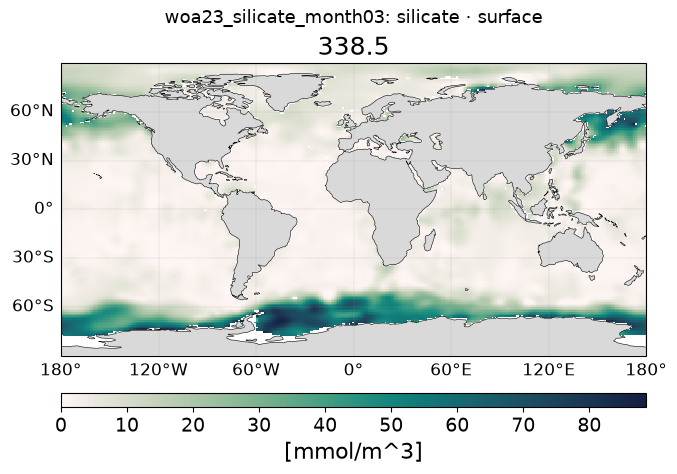

In [36]:
osk.field("woa23_silicate_month03", "silicate").plot()

## Compare model with data

### Grid

#### Compare one variable at multiple depths

  comparing 'dev' vs 'glodap' [1/1]


/tmp/ipykernel_304720/2670197678.py:1: UserWarning: 'alkalinity' resolved to standard_name 'sea_water_alkalinity_expressed_as_mole_equivalent' (compare variables=)
  bydepth = osk.compare(
/tmp/ipykernel_304720/2670197678.py:1: UserWarning: Entry name 'glodap' in /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/glodap.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/glodap.yaml; use 'glodap:glodap' to disambiguate.
  bydepth = osk.compare(
/tmp/ipykernel_304720/2670197678.py:1: UserWarning: Entry name 'glodap' in /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/glodap.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/glodap.yaml; use 'glodap:glodap' to disambiguate.
  bydepth = osk.compare(
/tmp/ipykernel_304720/2670197678.py:1: UserWarning: Entry name 'glodap' in /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/glodap.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/glod

  2 comparison(s) formed; 0 skipped


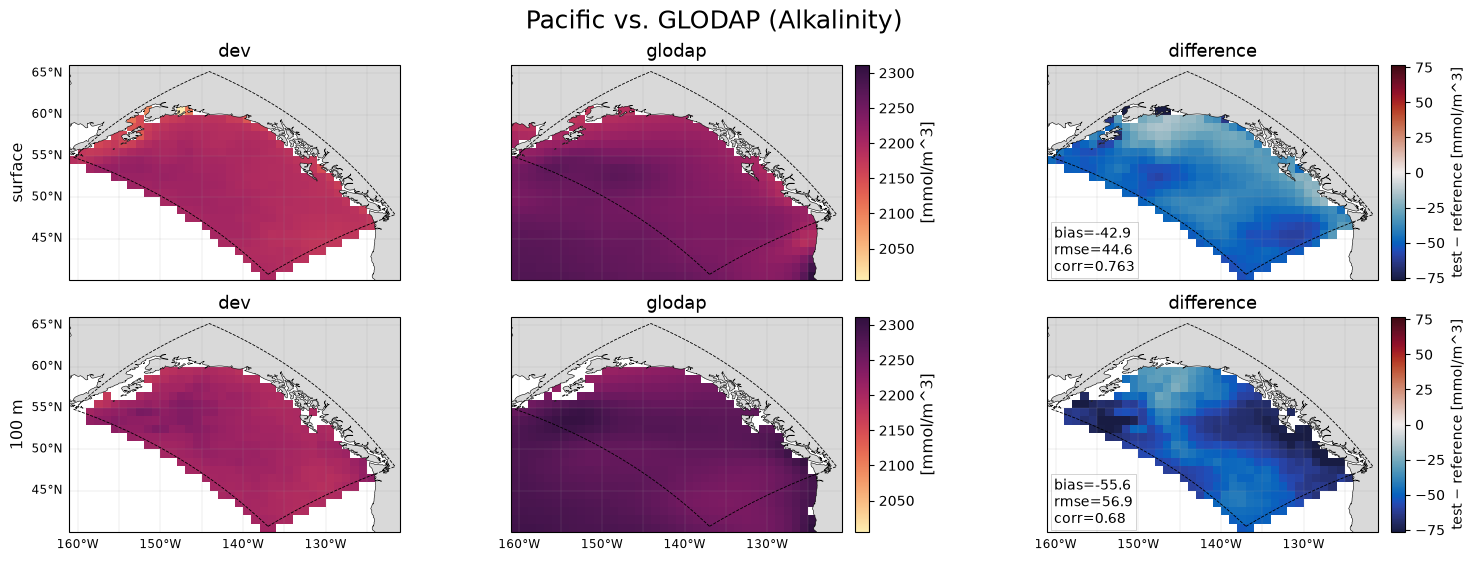

In [37]:
bydepth = osk.compare(
    aggregate={"time": "mean"},
    reference=["glodap"],
    test=model1a,
    variables=["alkalinity"],
    depths=["surface", 100],
)
bydepth.plot(figsize=(15, 5.5), title="Pacific vs. GLODAP (Alkalinity)", shared_limits=True,)

#### Compare many gridded dataset variables

/tmp/ipykernel_304720/128631615.py:7: UserWarning: 'nitrate' resolved to standard_name 'mole_concentration_of_nitrate_in_sea_water' (compare variables=)
  bgc = osk.compare(
/tmp/ipykernel_304720/128631615.py:7: UserWarning: 'phosphate' resolved to standard_name 'mole_concentration_of_phosphate_in_sea_water' (compare variables=)
  bgc = osk.compare(
/tmp/ipykernel_304720/128631615.py:7: UserWarning: 'silicate' resolved to standard_name 'mole_concentration_of_silicate_in_sea_water' (compare variables=)
  bgc = osk.compare(
/tmp/ipykernel_304720/128631615.py:7: UserWarning: 'oxygen' resolved to standard_name 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water' (compare variables=)
  bgc = osk.compare(
/tmp/ipykernel_304720/128631615.py:7: UserWarning: Entry name 'woa23_phosphate_month01' in /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/woa.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/woa.yaml; use 'woa:woa23_phosphate_month01' to d

  comparing nitrate 'dev' vs 'woa23_nitrate_month01' [1/1]
  comparing phosphate 'dev' vs 'woa23_phosphate_month01' [1/1]
  comparing silicate 'dev' vs 'woa23_silicate_month01' [1/1]
  comparing oxygen 'dev' vs 'woa23_oxygen_month01' [1/1]
  4 comparison(s) formed; 0 skipped


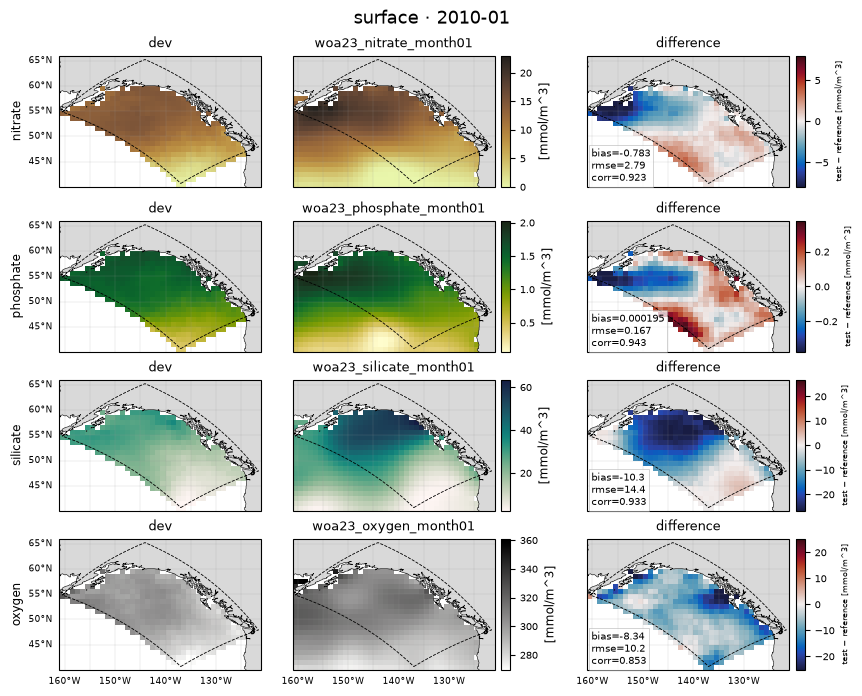

In [38]:
NITRATE = "nitrate"
PHOSPHATE = "phosphate"
SILICATE = "silicate"
OXYGEN = "oxygen"


bgc = osk.compare(
    reference=["woa23_nitrate_month01", "woa23_phosphate_month01", "woa23_silicate_month01", "woa23_oxygen_month01"],
    test=model1a,
    variables=[NITRATE, PHOSPHATE, SILICATE, OXYGEN],
    depths=["surface"],
    select={"test": {"time": "2010-01"}, "reference": {}},
    aggregate={"test": {"time": "mean"}, "reference": None},
)
bgc.plot()

/tmp/ipykernel_304720/529321008.py:7: UserWarning: 'nitrate' resolved to standard_name 'mole_concentration_of_nitrate_in_sea_water' (compare variables=)
  bgc100 = osk.compare(
/tmp/ipykernel_304720/529321008.py:7: UserWarning: 'phosphate' resolved to standard_name 'mole_concentration_of_phosphate_in_sea_water' (compare variables=)
  bgc100 = osk.compare(
/tmp/ipykernel_304720/529321008.py:7: UserWarning: 'silicate' resolved to standard_name 'mole_concentration_of_silicate_in_sea_water' (compare variables=)
  bgc100 = osk.compare(
/tmp/ipykernel_304720/529321008.py:7: UserWarning: 'oxygen' resolved to standard_name 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water' (compare variables=)
  bgc100 = osk.compare(
/tmp/ipykernel_304720/529321008.py:7: UserWarning: Entry name 'woa23_phosphate_month01' in /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/woa.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/woa.yaml; use 'woa:woa23_phosphate_m

  comparing nitrate 'dev' vs 'woa23_nitrate_month01' [1/1]
  comparing phosphate 'dev' vs 'woa23_phosphate_month01' [1/1]
  comparing silicate 'dev' vs 'woa23_silicate_month01' [1/1]
  comparing oxygen 'dev' vs 'woa23_oxygen_month01' [1/1]
  4 comparison(s) formed; 0 skipped


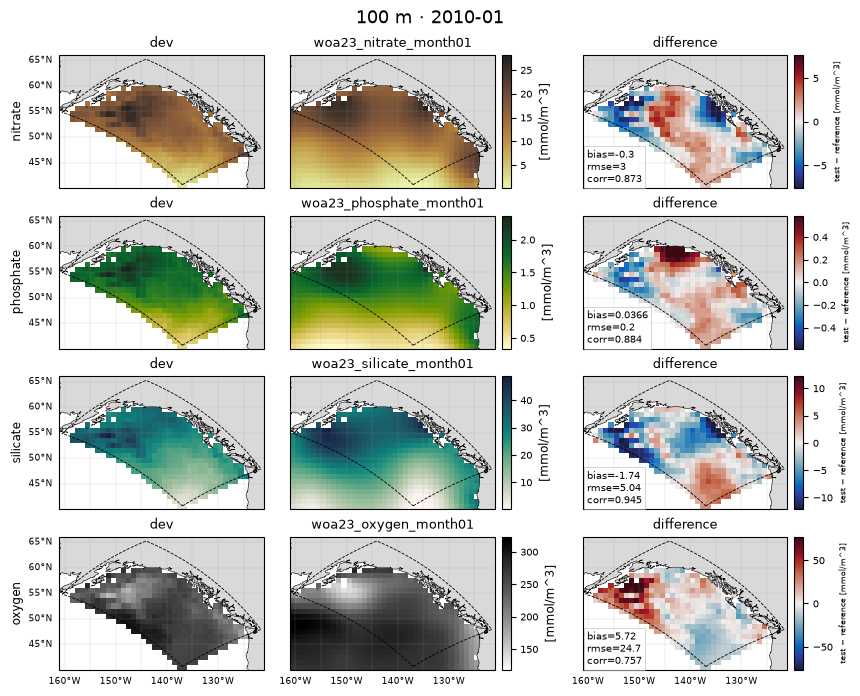

In [39]:
NITRATE = "nitrate"
PHOSPHATE = "phosphate"
SILICATE = "silicate"
OXYGEN = "oxygen"


bgc100 = osk.compare(
    reference=["woa23_nitrate_month01", "woa23_phosphate_month01", "woa23_silicate_month01", "woa23_oxygen_month01"],
    test=model1a,
    variables=[NITRATE, PHOSPHATE, SILICATE, OXYGEN],
    depths=["100"],
    select={"test": {"time": "2010-01"}, "reference": {}},
    aggregate={"test": {"time": "mean"}, "reference": None},
)
bgc100.plot()

#### Compare chlorophyll with derived field

<timed exec>:3: UserWarning: 'chlorophyll' resolved to standard_name 'mass_concentration_of_chlorophyll_a_in_sea_water' (compare variables=)
<timed exec>:3: UserWarning: Entry name 'chl_gapfree_my_daily_geo' in /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/docs/catalogs/copernicus.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/copernicus.yaml; use 'copernicus:chl_gapfree_my_daily_geo' to disambiguate.


  comparing 'dev' vs 'chl_gapfree_my_daily_geo' [1/1]
  1 comparison(s) formed; 0 skipped
CPU times: user 4.25 s, sys: 107 ms, total: 4.36 s
Wall time: 4.33 s


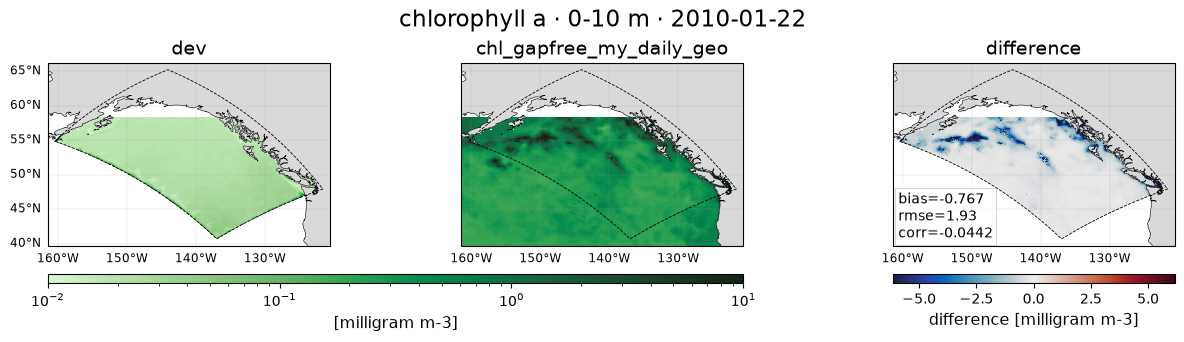

In [40]:
%%time

CHL = "chlorophyll"

chl = osk.compare(
    reference="chl_gapfree_my_daily_geo",
    test=model1a,
    variables=[{
        "test": {"sum": ["spChl", "diatChl", "diazChl"]},
        "reference": CHL,
        "standard_name": CHL,
    }],
    select={"T": "2010-01-22", "Z": {"min": 0, "max": 10}},
    aggregate={"Z": "mean"},
)

chl.plot(zoom=1.5)

#### Subset in space and show in time

In [41]:
osk.find(variable="temp",featureType="grid")

['NOAA_DHW',
 'erdMBsstd1day',
 'erdMH1sstd1day_R2022NRTMasked',
 'erdMH1sstd1day_R2022SQMasked',
 'erdMWsstd1day',
 'jplMURSST41',
 'jplMURSST41clim',
 'jplMURSST41mday',
 'jplMURSST42',
 'ncdcOisst21Agg',
 'nceiErsstv5',
 'nesdisVHNsstDaily',
 'productivity_viirs_snpp_daily',
 'productivity_viirs_snpp_nrt_daily',
 'glorys_climatology_geo',
 'glorys_climatology_timeseries',
 'glorys_my_daily_geo',
 'glorys_my_daily_timeseries',
 'sst_c3s_rep_daily_geo',
 'sst_c3s_rep_daily_timeseries',
 'sst_esacci_rep_daily_geo',
 'sst_esacci_rep_daily_timeseries',
 'sst_ostia_nrt_daily_geo',
 'sst_ostia_nrt_daily_timeseries',
 'glodap',
 'oceansoda',
 'WHOTS_200408-202108_D_FLTS-1H',
 'WHOTS_200408-202108_D_FLTS-1M',
 'woa23_temperature_annual',
 'woa23_temperature_month01',
 'woa23_temperature_month02',
 'woa23_temperature_month03',
 'woa23_temperature_month04',
 'woa23_temperature_month05',
 'woa23_temperature_month06',
 'woa23_temperature_month07',
 'woa23_temperature_month08',
 'woa23_temperatur

In [42]:
osk.describe("jplMURSST41")

source: coastwatch:jplMURSST41
  path: /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/coastwatch.yaml
  axes: {'T': 'time', 'X': 'longitude', 'Y': 'latitude'}
  featureType: grid
  featureType_source: inferred
  geospatial_lat_max: 89.98999786376953
  geospatial_lat_min: -89.98999786376953
  geospatial_lon_max: 180.0
  geospatial_lon_min: -179.99000549316406
  grid_regular: True
  grid_resolution_deg: 0.01
  grid_resolution_km: 1.112
  lon_convention: -180-180
  standard_names: {'analysed_sst': 'sea_surface_foundation_temperature', 'mask': 'land_binary_mask', 'sea_ice_fraction': 'sea_ice_area_fraction'}
  time_coverage_end: 2026-08-12
  time_coverage_start: 2002-06-01
  time_resolution: P1D
  time_resolution_s: 86400.0
  variables: ['land_binary_mask', 'sea_ice_area_fraction', 'sea_surface_foundation_temperature']
  vocabulary:
    matched (2):
      sea_ice      <- sea_ice_area_fraction
      temperature  <- sea_surface_foundation_temperature
    unmatched (1):
      land_binary_mask
  coordinates:
    matched (3):
      T (time)       <- time
      X (longitude)  <- longitude
      Y (latitude)   <- latitude
    missing (1): Z

In [43]:
osk.catalog.overlap(model1a, "jplMURSST42")

Overlap(space=yes, time=yes)

  comparing 'dev' vs 'jplMURSST42' [1/1]
  1 comparison(s) formed; 0 skipped


/tmp/ipykernel_304720/3937176490.py:9: UserWarning: 'sea_surface_temperature' resolved to standard_name 'sea_water_potential_temperature' (compare variables=)
  ts = osk.compare(
/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/comparison.py:5404: UserWarning: only 25 time steps: metrics are weakly constrained. Usually the two records overlap over only a short period, or the binning left few of them — see the aligned pair's attrs for what matched.
  self._metrics = _metrics.compute(


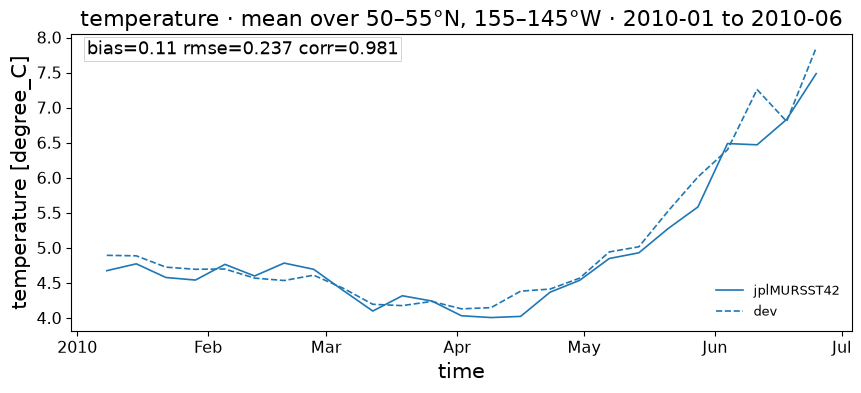

In [44]:

# The box — spelled with the existing select range vocabulary.
box = {
    "lon": {"min": -155.0, "max": -145.0},
    "lat": {"min": 50.0, "max": 55.0},
}

# 2. Box-mean timeseries: same box, area-weighted mean across space,
#    time left standing. over="time" is implied automatically.
ts = osk.compare(
    reference="jplMURSST42",
    test=model1a,
    variables=["sea_surface_temperature"],
    select=box,
    aggregate={"lat": "mean", "lon": "mean"},   # joint, area-weighted
)
ts.plot()                        

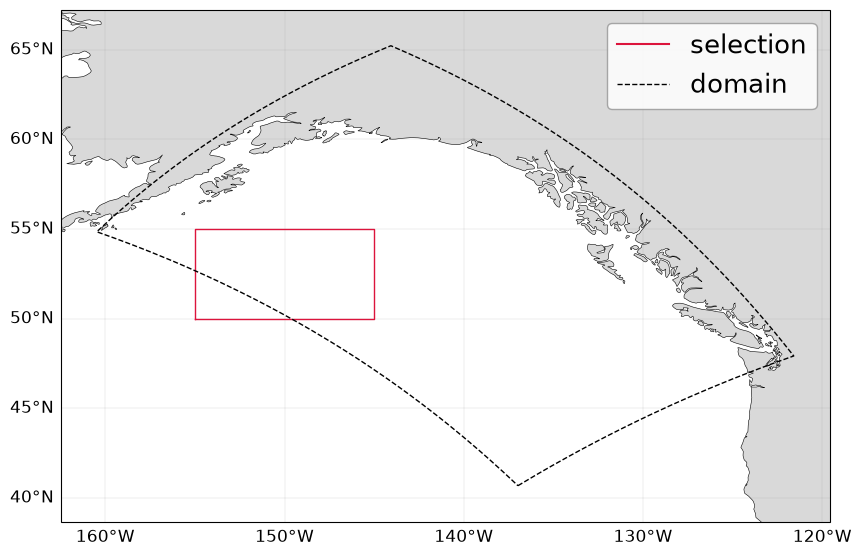

In [45]:
ts.map_locations()

#### Vertical slice comparison

/tmp/ipykernel_304720/3572328059.py:1: UserWarning: 'nitrate' resolved to standard_name 'mole_concentration_of_nitrate_in_sea_water' (compare variables=)
  comp_vs = osk.compare(
/tmp/ipykernel_304720/3572328059.py:1: UserWarning: Entry name 'woa23_nitrate_month01' in /mnt/cooltub/cw/cstar-forge-data/source-data/catalogs/woa.yaml shadows /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/woa.yaml; use 'woa:woa23_nitrate_month01' to disambiguate.
  comp_vs = osk.compare(


  comparing 'dev' vs 'woa23_nitrate_month01' [1/1]
  1 comparison(s) formed; 0 skipped


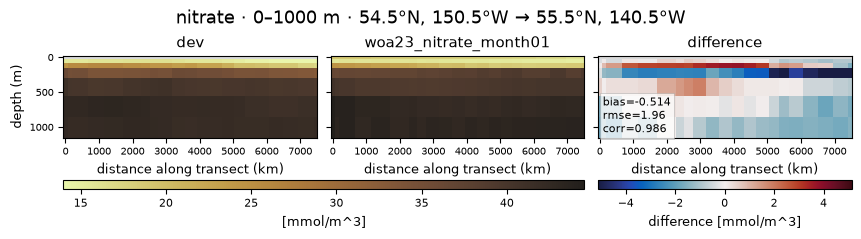

In [46]:
comp_vs = osk.compare(
    test=model1a, reference="woa23_nitrate_month01", variables=["nitrate"],
    select={"transect": {"waypoints": [[-150.0, 55.0], [-145.0, 55.0], [-140.0, 55.0]]},
            "depth": [0, 50, 100, 200, 400, 700, 1000]},
    aggregate={"time": "mean"},
)
comp_vs.plot()     # test | reference | difference sections + metrics

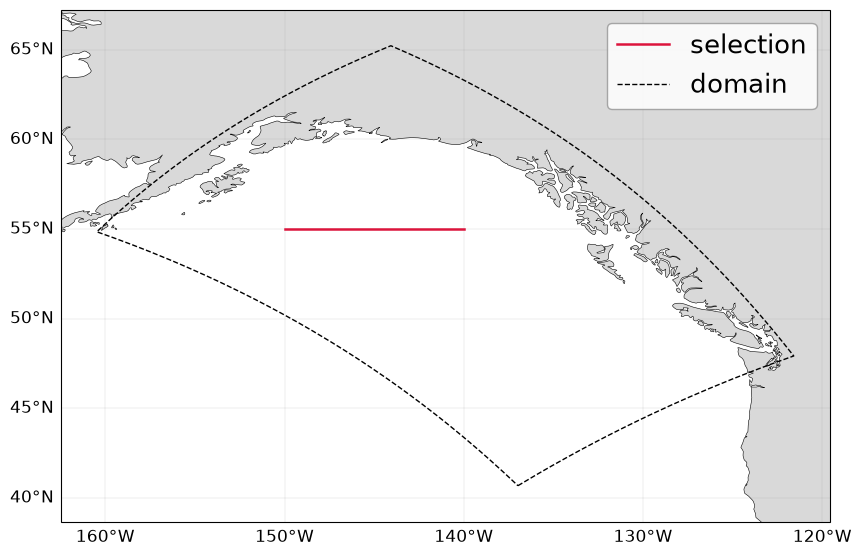

In [47]:
comp_vs.map_locations()

#### Summary Plots

/tmp/ipykernel_304720/279663585.py:2: UserWarning: Weighting by effective sample size 'n_eff' (pass summary_weights=None to disable).
  osk.summary(comps, marker_by="test", color_by="variable", summary_points="median", summary_split_markers=True, alpha=0.25, legend_style="grid")
/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/plot/summary.py:1609: UserWarning: summary_weights='n_eff': 1 of 13 records don't carry it and are weighted 1.0.
  overlay_specs += _summary_point_specs(
/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/plot/summary.py:1905: UserWarning: summary_weights='n_eff': 1 of 13 records don't carry it and are weighted 1.0.
  overlay_specs += _summary_point_specs(


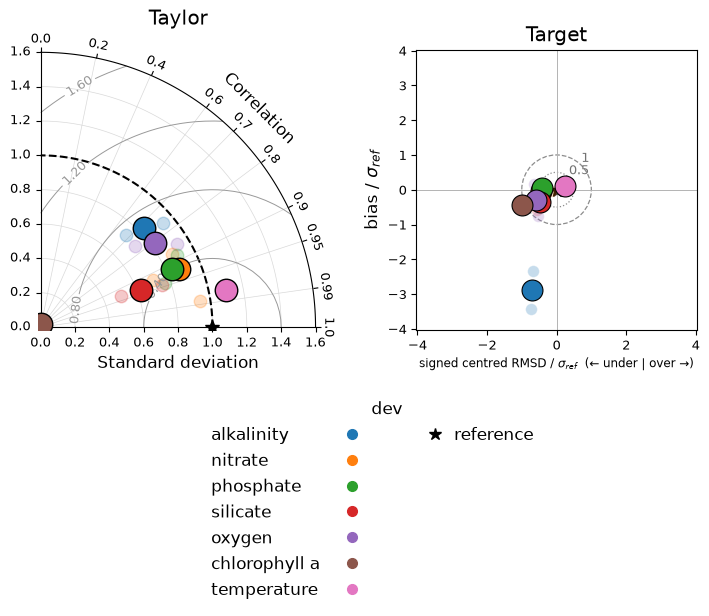

In [48]:
comps = osk.ComparisonSet([bydepth, bgc, bgc100, chl, ts, comp_vs])
osk.summary(comps, marker_by="test", color_by="variable", summary_points="median", summary_split_markers=True, alpha=0.25, legend_style="grid")

### timeSeries

  comparing salinity 'dev' vs 'papa_co2' [1/2]
  comparing salinity 'dev_marblsub' vs 'papa_co2' [2/2]


/tmp/ipykernel_304720/1148407975.py:1: UserWarning: 'salt' resolved to standard_name 'sea_water_practical_salinity' (compare variables=)
  comp_ts = osk.compare(reference="papa_co2", test=[model1a, model1b], variables=["salt","temp"])
/tmp/ipykernel_304720/1148407975.py:1: UserWarning: 'temp' resolved to standard_name 'sea_water_potential_temperature' (compare variables=)
  comp_ts = osk.compare(reference="papa_co2", test=[model1a, model1b], variables=["salt","temp"])


  comparing temperature 'dev' vs 'papa_co2' [1/2]
  comparing temperature 'dev_marblsub' vs 'papa_co2' [2/2]
  4 comparison(s) formed; 0 skipped


/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/comparison.py:5404: UserWarning: only 14 time steps: metrics are weakly constrained. Usually the two records overlap over only a short period, or the binning left few of them — see the aligned pair's attrs for what matched.
  self._metrics = _metrics.compute(
/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/comparison.py:5404: UserWarning: only 14 time steps: metrics are weakly constrained. Usually the two records overlap over only a short period, or the binning left few of them — see the aligned pair's attrs for what matched.
  self._metrics = _metrics.compute(
/mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/comparison.py:5404: UserWarning: only 14 time steps: metrics are weakly constrained. Usually the two records overlap over only a short period, or the binning left few of them — see the aligned pair's attrs for what matched.
  self._metrics = _metrics.compute(
/mnt/cooltub/cw/user/kthyng/projects/

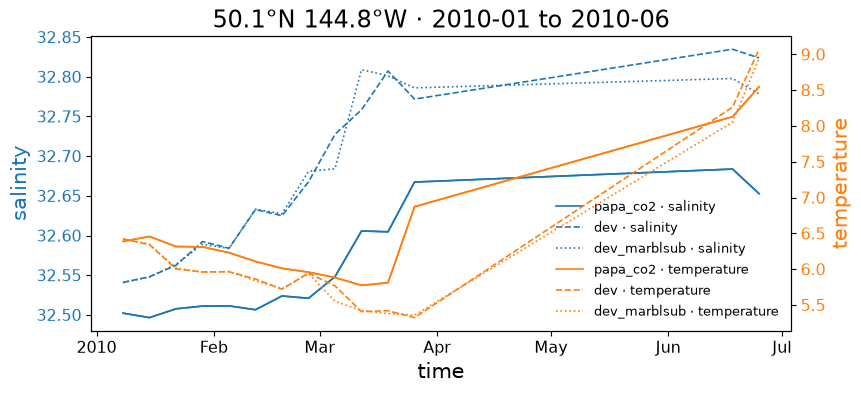

In [50]:
comp_ts = osk.compare(reference="papa_co2", test=[model1a, model1b], variables=["salt","temp"])
comp_ts.plot()

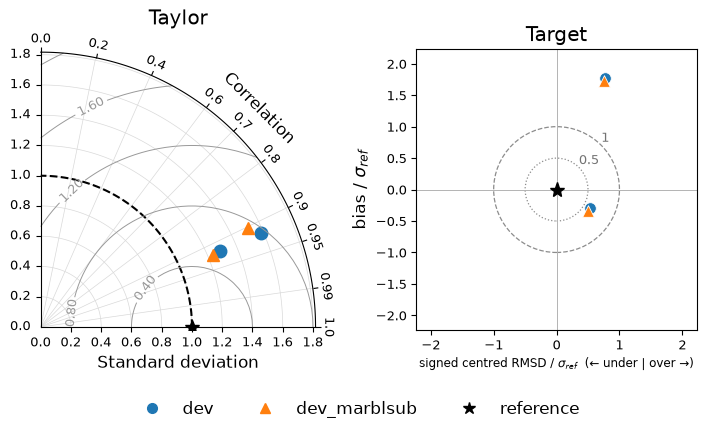

In [51]:
comp_ts.summary(marker_by="test")

### profile

/tmp/ipykernel_304720/596503125.py:1: UserWarning: 'salt' resolved to standard_name 'sea_water_practical_salinity' (compare variables=)
  comp_prof = osk.compare(reference="argo_4900453_c199", test=[model1a,model1b], variables=["salt","temp"])
/tmp/ipykernel_304720/596503125.py:1: UserWarning: 'temp' resolved to standard_name 'sea_water_potential_temperature' (compare variables=)
  comp_prof = osk.compare(reference="argo_4900453_c199", test=[model1a,model1b], variables=["salt","temp"])


  comparing salinity 'dev' vs 'argo_4900453_c199' [1/2]
  comparing salinity 'dev_marblsub' vs 'argo_4900453_c199' [2/2]
  comparing temperature 'dev' vs 'argo_4900453_c199' [1/2]
  comparing temperature 'dev_marblsub' vs 'argo_4900453_c199' [2/2]
  4 comparison(s) formed; 0 skipped


/tmp/ipykernel_304720/596503125.py:2: UserWarning: 4 distinct stats rows would share one panel, which would be a table drawn on a figure; it is left off. Every number is in the metrics CSV (ComparisonSet.save) either way.
  comp_prof.plot(zoom=0.7, metrics_stacked=True)


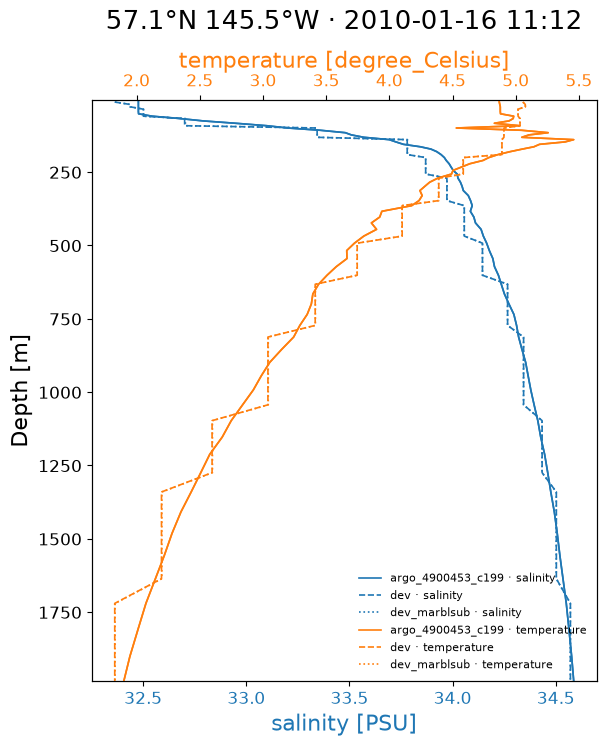

In [52]:
comp_prof = osk.compare(reference="argo_4900453_c199", test=[model1a,model1b], variables=["salt","temp"])
comp_prof.plot(zoom=0.7, metrics_stacked=True)

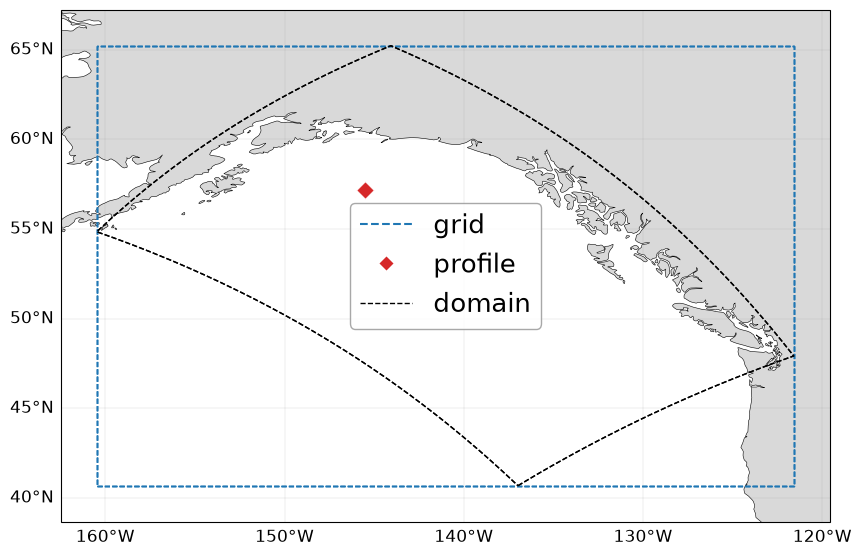

In [53]:
comp_prof.map_locations()

### timeSeriesProfile

In [54]:
comp_tsp = osk.compare(reference="papa_psal",
            test=[model1a,model1b],
            variables=["salt"],
           )

/tmp/ipykernel_304720/2323734754.py:1: UserWarning: 'salt' resolved to standard_name 'sea_water_practical_salinity' (compare variables=)
  comp_tsp = osk.compare(reference="papa_psal",


  comparing 'dev' vs 'papa_psal' [1/2]
  comparing 'dev_marblsub' vs 'papa_psal' [2/2]
  2 comparison(s) formed; 0 skipped


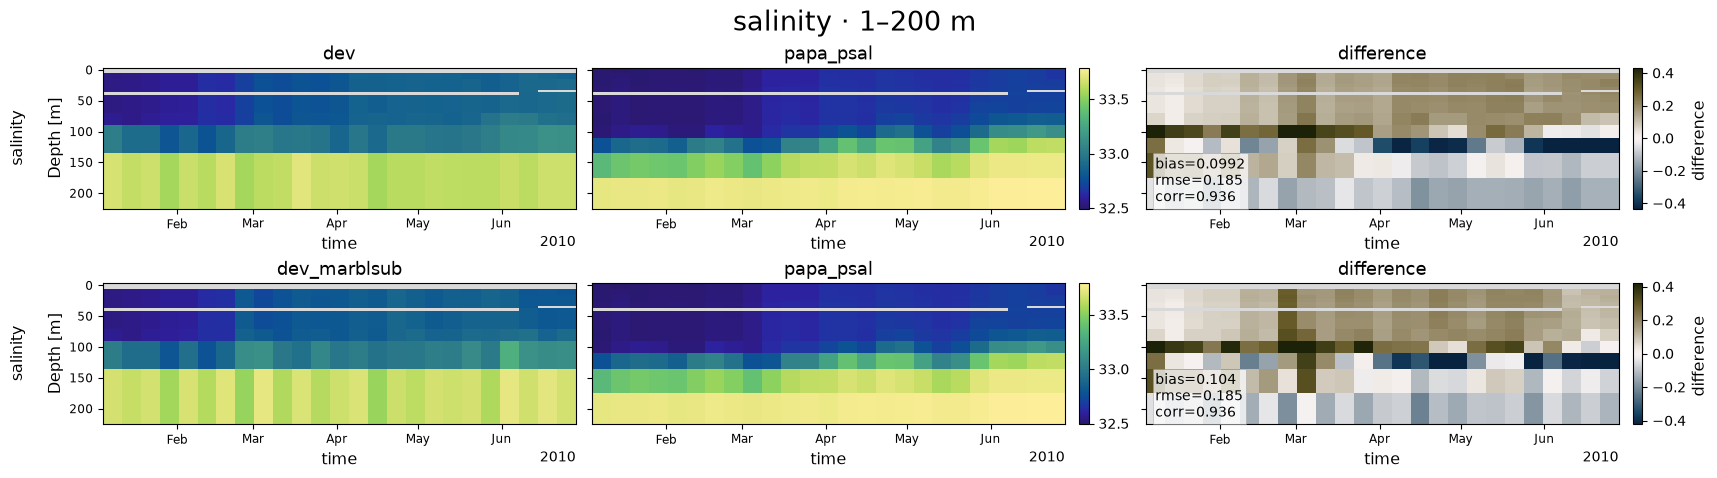

In [55]:
comp_tsp.plot(zoom=2)

### Summary Plots


In [56]:
comps = osk.ComparisonSet([comp_ts, comp_prof, comp_tsp])

/tmp/ipykernel_304720/1378744501.py:1: UserWarning: Weighting by effective sample size 'n_eff' (pass summary_weights=None to disable).
  osk.summary(comps, marker_by="test", color_by="variable", summary_points="median", summary_split_markers=True, alpha=0.25, legend_style="grid")


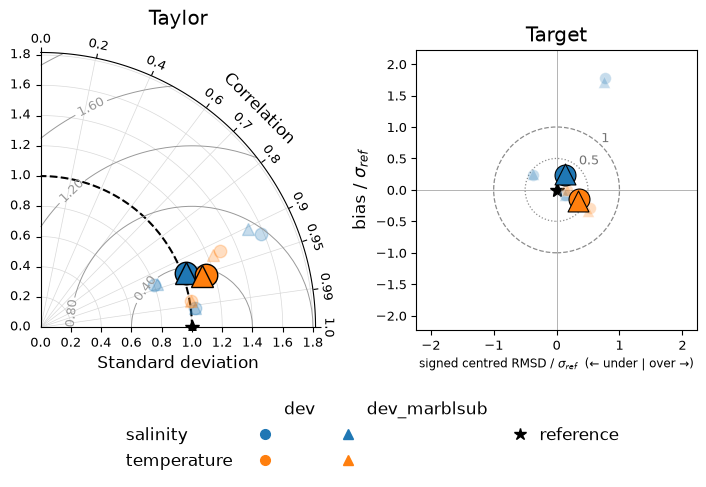

In [57]:
osk.summary(comps, marker_by="test", color_by="variable", summary_points="median", summary_split_markers=True, alpha=0.25, legend_style="grid")

/tmp/ipykernel_304720/1552215798.py:1: UserWarning: this set compares against 2 different test sources (['dev', 'dev_marblsub']) — using 'dev''s grid. Pass grid='regular' (or test=<name>) to choose deliberately.
  comps.map_metrics()
/tmp/ipykernel_304720/1552215798.py:1: UserWarning: Weighting by effective sample size 'n_eff' (pass weights=None to disable).
  comps.map_metrics()
/tmp/ipykernel_304720/1552215798.py:1: UserWarning: 7 record(s) shared a position (within 0.001°) with another and were pooled to their median before interpolating — 10 records became 3 positions.
  comps.map_metrics()
/tmp/ipykernel_304720/1552215798.py:1: UserWarning: only 3 stations carry 'bias' — too few to cross-validate a smoothing parameter, so a single fixed-damping spline is used instead. Treat this metric's map as a rougher sketch than the others.
  comps.map_metrics()
/home/kthyng/miniforge3/envs/ocean-skill/lib/python3.12/site-packages/verde/spline.py:455: UserWarning: Weights might have no effect 

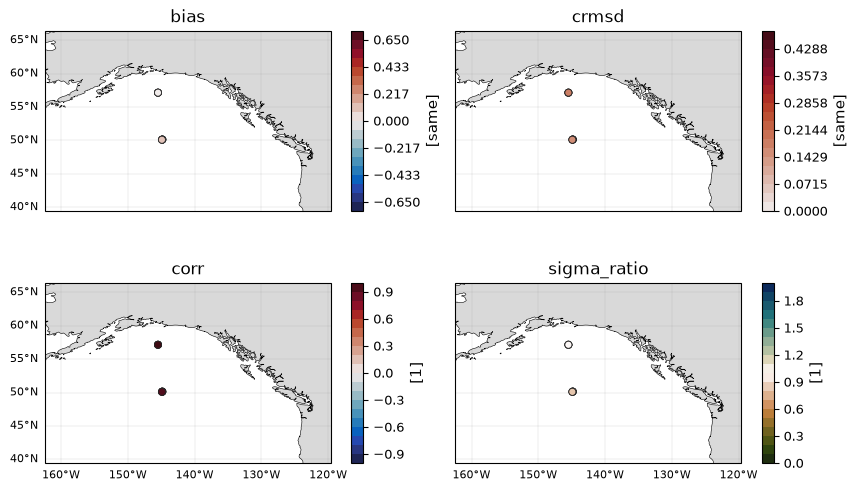

In [58]:
comps.map_metrics()

## Catalog methods

In [59]:
osk.find(catalog=cat_name).by_catalog()

{'ben_dev_tanagra': ['ccs', 'ccs_cdr', 'dev', 'dev_marblsub']}

### Available catalogs

In [60]:
osk.catalogs.catalog_names()

['argo_demo',
 'ben_dev_tanagra',
 'caloos_timeseries',
 'coastwatch',
 'copernicus',
 'glodap',
 'mld_climatologies',
 'modis_aqua',
 'oceansoda',
 'ooi_papa',
 'papa_timeseries',
 'smallgrid',
 'whots',
 'woa']

### Look at available data sources

`osk.catalogs` or `list(osk.catalogs)` or `osk.catalogs.names()`

In [61]:
list(osk.catalogs)

['NOAA_DHW',
 'NWW3_Global_Best',
 'erdMBsstd1day',
 'erdMH1cflh1day_R2022NRT',
 'erdMH1cflh1day_R2022SQ',
 'erdMH1chla1day_R2022NRT',
 'erdMH1chla1day_R2022SQ',
 'erdMH1sstd1day_R2022NRTMasked',
 'erdMH1sstd1day_R2022SQMasked',
 'erdMPIC1day_R2022NRT',
 'erdMPIC1day_R2022SQ',
 'erdMPOC1day_R2022NRT',
 'erdMPOC1day_R2022SQ',
 'erdMWchla1day',
 'erdMWsstd1day',
 'erdQCwindproducts1day',
 'jplMURSST41',
 'jplMURSST41anom1day',
 'jplMURSST41clim',
 'jplMURSST41mday',
 'jplMURSST42',
 'ncdcOisst21Agg',
 'nceiErsstv5',
 'nesdisVHNsstDaily',
 'noaacwNPPN20S3ASCIDINEOF2kmDaily',
 'noaacwNPPN20S3AkdSCIDINEOF2kmDaily',
 'noaacwNPPN20S3AspmSCIDINEOF2kmDaily',
 'nsidcG02202v6nh1day',
 'nsidcG02202v6sh1day',
 'productivity_viirs_snpp_daily',
 'productivity_viirs_snpp_nrt_daily',
 'chl_climatology_doy_geo',
 'chl_climatology_doy_timeseries',
 'chl_gapfree_my_daily_geo',
 'chl_gapfree_my_daily_timeseries',
 'chl_gapfree_nrt_daily_geo',
 'chl_gapfree_nrt_daily_timeseries',
 'cur_multiobs_my_daily_geo

### List sources and metadata from one catalog

In [63]:
osk.describe('modis_aqua')

catalog: modis_aqua
  featureTypes: ['grid']
  geospatial_lat_max: 89.95833587646484
  geospatial_lat_min: -89.95833587646484
  geospatial_lon_max: 179.95834350585938
  geospatial_lon_min: -179.9583282470703
  standard_names: ['mass_concentration_of_chlorophyll_in_sea_water']
  title: MODIS Aqua
  sources (519): MODIS Aqua chlorophyll a 32-day rolling 2003-01-01 to 2003-02-01 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-01-09 to 2003-02-09 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-01-17 to 2003-02-17 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-01-25 to 2003-02-25 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-02-02 to 2003-03-05 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-02-10 to 2003-03-13 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-02-18 to 2003-03-21 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-02-26 to 2003-03-29 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-03-06 to 2003-04-06 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-03-14 to 2003-04-14 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-03-22 to 2003-04-22 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-03-30 to 2003-04-30 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-04-07 to 2003-05-08 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-04-15 to 2003-05-16 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-04-23 to 2003-05-24 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-05-01 to 2003-06-01 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-05-09 to 2003-06-09 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-05-17 to 2003-06-17 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-05-25 to 2003-06-25 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-06-02 to 2003-07-03 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-06-10 to 2003-07-11 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-06-18 to 2003-07-19 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-06-26 to 2003-07-27 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-07-04 to 2003-08-04 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-07-12 to 2003-08-12 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-07-20 to 2003-08-20 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-07-28 to 2003-08-28 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-08-05 to 2003-09-05 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-08-13 to 2003-09-13 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-08-21 to 2003-09-21 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-08-29 to 2003-09-29 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-09-06 to 2003-10-07 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-09-14 to 2003-10-15 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-09-22 to 2003-10-23 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-09-30 to 2003-10-31 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-10-08 to 2003-11-08 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-10-16 to 2003-11-16 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-10-24 to 2003-11-24 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-11-01 to 2003-12-02 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-11-09 to 2003-12-10 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-11-17 to 2003-12-18 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-11-25 to 2003-12-26 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-12-03 to 2004-01-03 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-12-11 to 2004-01-11 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-12-19 to 2004-01-19 9km, MODIS Aqua chlorophyll a 32-day rolling 2003-12-27 to 2004-01-27 9km, MODIS Aqua chlorophyll a 8-day 2003-01-01 to 2003-01-08 9km, MODIS Aqua chlorophyll a 8-day 2003-01-09 to 2003-01-16 9km, MODIS Aqua chlorophyll a 8-day 2003-01-17 to 2003-01-24 9km, MODIS Aqua chlorophyll a 8-day 2003-01-25 to 2003-02-01 9km, MODIS Aqua chlorophyll a 8-day 2003-02-02 to 2003-02-09 9km, MODIS Aqua chlorophyll a 8-day 2003-02-10 to 2003-02-17 9km, MODIS Aqua chlorophyll a 8-day 2003-02-18 to 2003-02-25 9km, MODIS Aqua chlorophyll a 8-day 2003-02-

### Search across catalogs

There are a bunch of search terms to use to narrow results.

In [64]:
osk.find?

Signature:
osk.find(
    *,
    text: 'str | list[str] | None' = None,
    name: 'str | None' = None,
    catalog: 'str | None' = None,
    title: 'str | None' = None,
    description: 'str | None' = None,
    climatology: 'bool | str | None' = None,
    variable: 'str | None' = None,
    featureType: 'str | None' = None,
    bbox: 'tuple[float, float, float, float] | None' = None,
    time: 'tuple[str, str] | None' = None,
    resolution: 'float | tuple[float | None, float | None] | None' = None,
    cadence: 'str | float | tuple[float | None, float | None] | None' = None,
    vertical: 'bool | None' = None,
) -> 'SourceNames'
Docstring:
Search discovered sources by name and metadata; return matching source names.

Parameters
----------
text
    Free-text query: ``str`` or list of terms, all ANDed. Matches anywhere in
    a source's name, its catalog's name/title/description, or its metadata
    (summary, institution, period, declared variables). ``None`` (default)
    skips this filt

In [65]:
osk.find(climatology="January", resolution=5)

['woa23_salinity_month01', 'woa23_temperature_month01']

In [66]:
osk.find(cadence="daily", vertical=True)

['cur_multiobs_my_daily_geo',
 'cur_multiobs_my_daily_timeseries',
 'cur_multiobs_nrt_daily_geo',
 'cur_multiobs_nrt_daily_timeseries',
 'glorys_my_daily_geo',
 'glorys_my_daily_timeseries',
 'glodap',
 'woa23_nitrate_month01',
 'woa23_nitrate_month02',
 'woa23_nitrate_month03',
 'woa23_nitrate_month04',
 'woa23_nitrate_month05',
 'woa23_nitrate_month06',
 'woa23_nitrate_month07',
 'woa23_nitrate_month08',
 'woa23_nitrate_month09',
 'woa23_nitrate_month10',
 'woa23_nitrate_month11',
 'woa23_nitrate_month12',
 'woa23_oxygen_month01',
 'woa23_oxygen_month02',
 'woa23_oxygen_month03',
 'woa23_oxygen_month04',
 'woa23_oxygen_month05',
 'woa23_oxygen_month06',
 'woa23_oxygen_month07',
 'woa23_oxygen_month08',
 'woa23_oxygen_month09',
 'woa23_oxygen_month10',
 'woa23_oxygen_month11',
 'woa23_oxygen_month12',
 'woa23_phosphate_month01',
 'woa23_phosphate_month02',
 'woa23_phosphate_month03',
 'woa23_phosphate_month04',
 'woa23_phosphate_month05',
 'woa23_phosphate_month06',
 'woa23_phosphate_

In [67]:
osk.find(catalog="soda")

['oceansoda']

In [68]:
osk.find(featureType="grid")

['NOAA_DHW',
 'NWW3_Global_Best',
 'erdMBsstd1day',
 'erdMH1cflh1day_R2022NRT',
 'erdMH1cflh1day_R2022SQ',
 'erdMH1chla1day_R2022NRT',
 'erdMH1chla1day_R2022SQ',
 'erdMH1sstd1day_R2022NRTMasked',
 'erdMH1sstd1day_R2022SQMasked',
 'erdMPIC1day_R2022NRT',
 'erdMPIC1day_R2022SQ',
 'erdMPOC1day_R2022NRT',
 'erdMPOC1day_R2022SQ',
 'erdMWchla1day',
 'erdMWsstd1day',
 'erdQCwindproducts1day',
 'jplMURSST41',
 'jplMURSST41anom1day',
 'jplMURSST41clim',
 'jplMURSST41mday',
 'jplMURSST42',
 'ncdcOisst21Agg',
 'nceiErsstv5',
 'nesdisVHNsstDaily',
 'noaacwNPPN20S3ASCIDINEOF2kmDaily',
 'noaacwNPPN20S3AkdSCIDINEOF2kmDaily',
 'noaacwNPPN20S3AspmSCIDINEOF2kmDaily',
 'nsidcG02202v6nh1day',
 'nsidcG02202v6sh1day',
 'productivity_viirs_snpp_daily',
 'productivity_viirs_snpp_nrt_daily',
 'chl_climatology_doy_geo',
 'chl_climatology_doy_timeseries',
 'chl_gapfree_my_daily_geo',
 'chl_gapfree_my_daily_timeseries',
 'chl_gapfree_nrt_daily_geo',
 'chl_gapfree_nrt_daily_timeseries',
 'cur_multiobs_my_daily_geo

In [69]:
osk.find(name="papa", featureType="timeSeries")

['ooi-gp02hypm-rim01-02-ctdmog039',
 'ooi-gp02hypm-wfp02-01-flordl000',
 'ooi-gp02hypm-wfp02-03-dostal000',
 'ooi-gp02hypm-wfp02-04-ctdpfl000',
 'ooi-gp02hypm-wfp02-05-vel3dl000',
 'ooi-gp02hypm-wfp03-01-flordl000',
 'ooi-gp02hypm-wfp03-03-dostal000',
 'ooi-gp02hypm-wfp03-04-ctdpfl000',
 'ooi-gp02hypm-wfp03-05-vel3dl000',
 'ooi-gp03flma-rim01-02-adcpsl003',
 'ooi-gp03flma-rim01-02-ctdmog040',
 'ooi-gp03flma-rim01-02-ctdmog041',
 'ooi-gp03flma-rim01-02-ctdmog042',
 'ooi-gp03flma-rim01-02-ctdmog043',
 'ooi-gp03flma-rim01-02-ctdmog044',
 'ooi-gp03flma-rim01-02-ctdmog045',
 'ooi-gp03flma-rim01-02-ctdmog046',
 'ooi-gp03flma-rim01-02-ctdmog047',
 'ooi-gp03flma-rim01-02-ctdmog048',
 'ooi-gp03flma-rim01-02-ctdmoh049',
 'ooi-gp03flma-rim01-02-ctdmoh050',
 'ooi-gp03flma-rim01-02-ctdmoh051',
 'ooi-gp03flma-ris01-03-dostad000',
 'ooi-gp03flma-ris01-04-phsenf000',
 'ooi-gp03flma-ris01-05-flortd000',
 'ooi-gp03flmb-rim01-02-adcpsl007',
 'ooi-gp03flmb-rim01-02-ctdmog060',
 'ooi-gp03flmb-rim01-02-ctdm

In [70]:
osk.find(variable="temperature")

['NOAA_DHW',
 'erdMBsstd1day',
 'erdMH1sstd1day_R2022NRTMasked',
 'erdMH1sstd1day_R2022SQMasked',
 'erdMWsstd1day',
 'jplMURSST41',
 'jplMURSST41clim',
 'jplMURSST41mday',
 'jplMURSST42',
 'ncdcOisst21Agg',
 'nceiErsstv5',
 'nesdisVHNsstDaily',
 'productivity_viirs_snpp_daily',
 'productivity_viirs_snpp_nrt_daily',
 'glorys_climatology_geo',
 'glorys_climatology_timeseries',
 'glorys_my_daily_geo',
 'glorys_my_daily_timeseries',
 'sst_c3s_rep_daily_geo',
 'sst_c3s_rep_daily_timeseries',
 'sst_esacci_rep_daily_geo',
 'sst_esacci_rep_daily_timeseries',
 'sst_ostia_nrt_daily_geo',
 'sst_ostia_nrt_daily_timeseries',
 'glodap',
 'oceansoda',
 'ooi-gp02hypm-rim01-02-ctdmog039',
 'ooi-gp03flma-rim01-02-ctdmog040',
 'ooi-gp03flma-rim01-02-ctdmog041',
 'ooi-gp03flma-rim01-02-ctdmog042',
 'ooi-gp03flma-rim01-02-ctdmog043',
 'ooi-gp03flma-rim01-02-ctdmog044',
 'ooi-gp03flma-rim01-02-ctdmog045',
 'ooi-gp03flma-rim01-02-ctdmog046',
 'ooi-gp03flma-rim01-02-ctdmog047',
 'ooi-gp03flma-rim01-02-ctdmog0

### Examine metadata in a source within a catalog

Note that matched variables and coordinates are indicated at the bottom according to the active vocabulary at the moment (this is not saved into the catalog).

In [71]:
osk.describe("NOAA_DHW")

source: coastwatch:NOAA_DHW
  path: /mnt/cooltub/cw/user/kthyng/projects/ocean-skill/ocean_skill/catalogs/coastwatch.yaml
  axes: {'T': 'time', 'X': 'longitude', 'Y': 'latitude'}
  featureType: grid
  featureType_source: inferred
  geospatial_lat_max: 89.9749984741211
  geospatial_lat_min: -89.9749984741211
  geospatial_lon_max: 179.97500610351562
  geospatial_lon_min: -179.97500610351562
  grid_regular: True
  grid_resolution_deg: 0.049999
  grid_resolution_km: 5.56
  lon_convention: -180-180
  standard_names: {'CRW_SEAICE': 'sea_ice_area_fraction', 'CRW_SST': 'sea_surface_temperature'}
  time_coverage_end: 2026-08-12
  time_coverage_start: 1985-04-01
  time_resolution: P1D
  time_resolution_s: 86400.0
  variables: ['sea_ice_area_fraction', 'sea_surface_temperature']
  vocabulary:
    matched (2):
      sea_ice      <- sea_ice_area_fraction
      temperature  <- sea_surface_temperature
    unmatched (0)
  coordinates:
    matched (3):
      T (time)       <- time
      X (longitude)  <- longitude
      Y (latitude)   <- latitude
    missing (1): Z

### Read in source

`osk.read(SOURCE_NAME)`

Note that many time series sources are backed by ERDDAP servers so they can be queried using ERDDAP constraints, which can greatly speed up their read in timing if you limit the amount of time read in. Many gridded datasets are lazily read in without any special inputs.

In [72]:
osk.read("NOAA_DHW")

<xarray.Dataset> Size: 27TB
Dimensions:                  (time: 15142, latitude: 3600, longitude: 7200)
Coordinates:
  * time                     (time) datetime64[ns] 121kB 1985-04-01T12:00:00 ...
  * latitude                 (latitude) float32 14kB 89.97 89.93 ... -89.97
  * longitude                (longitude) float32 29kB -180.0 -179.9 ... 180.0
Data variables:
    CRW_BAA                  (time, latitude, longitude) float32 2TB dask.array<chunksize=(667, 158, 317), meta=np.ndarray>
    CRW_BAA_mask             (time, latitude, longitude) float32 2TB dask.array<chunksize=(667, 158, 317), meta=np.ndarray>
    CRW_BAA_7D_MAX           (time, latitude, longitude) float32 2TB dask.array<chunksize=(667, 158, 317), meta=np.ndarray>
    CRW_BAA_7D_MAX_mask      (time, latitude, longitude) float32 2TB dask.array<chunksize=(667, 158, 317), meta=np.ndarray>
    CRW_DHW                  (time, latitude, longitude) float64 3TB dask.array<chunksize=(532, 125, 251), meta=np.ndarray>
    CRW_DHW_mask             (time, latitude, longitude) float32 2TB dask.array<chunksize=(667, 158, 317), meta=np.ndarray>
    CRW_HOTSPOT              (time, latitude, longitude) float64 3TB dask.array<chunksize=(532, 125, 251), meta=np.ndarray>
    CRW_HOTSPOT_mask         (time, latitude, longitude) float32 2TB dask.array<chunksize=(667, 158, 317), meta=np.ndarray>
    sea_ice_area_fraction    (time, latitude, longitude) float64 3TB dask.array<chunksize=(532, 125, 251), meta=np.ndarray>
    sea_surface_temperature  (time, latitude, longitude) float64 3TB dask.array<chunksize=(532, 125, 251), meta=np.ndarray>
    CRW_SSTANOMALY           (time, latitude, longitude) float64 3TB dask.array<chunksize=(532, 125, 251), meta=np.ndarray>
    CRW_SSTANOMALY_mask      (time, latitude, longitude) float32 2TB dask.array<chunksize=(667, 158, 317), meta=np.ndarray>
Attributes: (12/63)
    acknowledgement:            NOAA Coral Reef Watch (CRW)
    cdm_data_type:              Grid
    comment:                    This product is designed to improve on and re...
    Conventions:                CF-1.6, ACDD-1.3
    creator_email:              coralreefwatch@noaa.gov
    creator_institution:        NOAA Coral Reef Watch (CRW)
    ...                         ...
    time_coverage_duration:     P1D
    time_coverage_end:          2026-09-21T12:00:00Z
    time_coverage_resolution:   P1D
    time_coverage_start:        1985-04-01T12:00:00Z
    title:                      NOAA Coral Reef Watch Operational Daily Near-...
    Westernmost_Easting:        -179.975

In [73]:
osk.read('ooi-gp02hypm-rim01-02-ctdmog039', constraints={"time>=": "2025-01-01"})

,time (UTC),latitude (degrees_north),longitude (degrees_east),z (m),sea_water_electrical_conductivity,sea_water_electrical_conductivity_qc_agg,sea_water_electrical_conductivity_qc_tests,depth_reading,depth_reading_qc_agg,depth_reading_qc_tests,...,sea_water_density,sea_water_density_qc_agg,sea_water_density_qc_tests,sea_water_pressure,sea_water_pressure_qc_agg,sea_water_pressure_qc_tests,sea_water_temperature,sea_water_temperature_qc_agg,sea_water_temperature_qc_tests,station
0,2025-01-01 00:00:00+00:00,50.069483,-144.8022,0.0,33.067903,1,NaN,154.683246,2,NaN,...,1027.283527,2,NaN,156.081226,1,NaN,5.755385,1,NaN,NaN
1,2025-01-01 00:15:00+00:00,50.069483,-144.8022,0.0,33.023828,1,NaN,154.757224,2,NaN,...,1027.310578,2,NaN,156.155901,1,NaN,5.683047,1,NaN,NaN
2,2025-01-01 00:30:00+00:00,50.069483,-144.8022,0.0,32.908817,1,NaN,154.471591,2,NaN,...,1027.309873,2,NaN,155.867578,1,NaN,5.569774,1,NaN,NaN
3,2025-01-01 00:45:00+00:00,50.069483,-144.8022,0.0,33.008620,1,NaN,154.406691,2,NaN,...,1027.293988,2,NaN,155.802066,1,NaN,5.684662,1,NaN,NaN
4,2025-01-01 01:00:00+00:00,50.069483,-144.8022,0.0,33.045950,1,NaN,154.265036,2,NaN,...,1027.286557,2,NaN,155.659077,1,NaN,5.728645,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14012,2025-08-21 16:00:00+00:00,50.069483,-144.8022,0.0,32.616100,1,NaN,161.631699,2,NaN,...,1027.386575,2,NaN,163.094582,1,NaN,5.231100,1,NaN,NaN
14013,2025-08-22 00:00:00+00:00,50.069483,-144.8022,0.0,32.584400,1,NaN,162.916393,2,NaN,...,1027.382133,2,NaN,164.391420,1,NaN,5.210600,1,NaN,NaN
14014,2025-08-22 08:00:00+00:00,50.069483,-144.8022,0.0,32.546700,1,NaN,163.937104,2,NaN,...,1027.420386,2,NaN,165.421784,1,NaN,5.136300,1,NaN,NaN
14015,2025-08-24 04:00:00+00:00,50.069483,-144.8022,0.0,32.604900,1,NaN,162.089263,2,NaN,...,1027.369964,2,NaN,163.556470,1,NaN,5.240300,1,NaN,NaN


In [74]:
osk.read("noaa_nos_co_ops_9414746", constraints={"time>=": "2026-01-01"})

,time (UTC),latitude (degrees_north),longitude (degrees_east),z (m),sea_surface_height_amplitude_due_to_geocentric_ocean_tide_above_mllw,sea_surface_height_amplitude_due_to_geocentric_ocean_tide_above_mllw_qc_agg,sea_surface_height_amplitude_due_to_geocentric_ocean_tide_above_mllw_qc_tests,station
0,2026-01-01 00:00:00+00:00,37.7717,-122.235,0.0,-36.3,2,NaN,NaN
1,2026-01-01 00:06:00+00:00,37.7717,-122.235,0.0,-35.5,2,NaN,NaN
2,2026-01-01 00:12:00+00:00,37.7717,-122.235,0.0,-34.6,2,NaN,NaN
3,2026-01-01 00:18:00+00:00,37.7717,-122.235,0.0,-33.4,2,NaN,NaN
4,2026-01-01 00:24:00+00:00,37.7717,-122.235,0.0,-32.0,2,NaN,NaN
...,...,...,...,...,...,...,...,...
65036,2026-09-28 23:36:00+00:00,37.7717,-122.235,0.0,101.0,2,NaN,NaN
65037,2026-09-28 23:42:00+00:00,37.7717,-122.235,0.0,95.5,2,NaN,NaN
65038,2026-09-28 23:48:00+00:00,37.7717,-122.235,0.0,90.1,2,NaN,NaN
65039,2026-09-28 23:54:00+00:00,37.7717,-122.235,0.0,84.7,2,NaN,NaN


In [75]:
osk.find(featureType="timeSeries")

['ooi-gp02hypm-rim01-02-ctdmog039',
 'ooi-gp02hypm-wfp02-01-flordl000',
 'ooi-gp02hypm-wfp02-03-dostal000',
 'ooi-gp02hypm-wfp02-04-ctdpfl000',
 'ooi-gp02hypm-wfp02-05-vel3dl000',
 'ooi-gp02hypm-wfp03-01-flordl000',
 'ooi-gp02hypm-wfp03-03-dostal000',
 'ooi-gp02hypm-wfp03-04-ctdpfl000',
 'ooi-gp02hypm-wfp03-05-vel3dl000',
 'ooi-gp03flma-rim01-02-adcpsl003',
 'ooi-gp03flma-rim01-02-ctdmog040',
 'ooi-gp03flma-rim01-02-ctdmog041',
 'ooi-gp03flma-rim01-02-ctdmog042',
 'ooi-gp03flma-rim01-02-ctdmog043',
 'ooi-gp03flma-rim01-02-ctdmog044',
 'ooi-gp03flma-rim01-02-ctdmog045',
 'ooi-gp03flma-rim01-02-ctdmog046',
 'ooi-gp03flma-rim01-02-ctdmog047',
 'ooi-gp03flma-rim01-02-ctdmog048',
 'ooi-gp03flma-rim01-02-ctdmoh049',
 'ooi-gp03flma-rim01-02-ctdmoh050',
 'ooi-gp03flma-rim01-02-ctdmoh051',
 'ooi-gp03flma-ris01-03-dostad000',
 'ooi-gp03flma-ris01-04-phsenf000',
 'ooi-gp03flma-ris01-05-flortd000',
 'ooi-gp03flmb-rim01-02-adcpsl007',
 'ooi-gp03flmb-rim01-02-ctdmog060',
 'ooi-gp03flmb-rim01-02-ctdm

### See if two sources overlap

In [76]:
osk.overlap("ccs", "NOAA_DHW")

Overlap(space=yes, time=yes)

### Map locations from catalogs

In [77]:
osk.map_locations?

Signature:
osk.map_locations(
    what: 'Any' = None,
    *,
    catalog: 'str | None' = None,
    renderer: 'str' = 'matplotlib',
    domain: 'Any' = <object object at 0x74290e5ab6b0>,
    **kwargs: 'Any',
)
Docstring:
Map where something sits: catalog datasets, or a plotted selection.

Parameters
----------
what
    ``None`` (default, everything discoverable), a catalog source name
    (``str``), a :func:`~ocean_skill.catalog.find` result, a
    :class:`~ocean_skill.comparison.Comparison`,
    :class:`~ocean_skill.comparison.ComparisonSet`,
    :class:`~ocean_skill.field.Field`, :class:`~ocean_skill.field.FieldSet`,
    or a list mixing names and such objects.
catalog
    Restrict a name-based (metadata-only) lookup to one catalog (``str``), or
    ``None`` (default) to search all discovered catalogs. Ignored for object
    input.
renderer
    One of ``"matplotlib"``, ``"holoviews"`` (default ``"matplotlib"``).
domain
    Object input only: the default outlines each distinct test sou

In [ ]:
fig = osk.map_locations(catalog="OOI*", renderer="holoviews")
fig

In [ ]:
fig = osk.find(variable="nitrate").map(renderer="holoviews")
fig

## Vocabulary handling

This package takes inspiration from `cf-xarray` to track coordinate and variable names. It uses a combination of known aliases and regular expressions to recognize different versions of names for variables. 

Here are the dictionaries used to recognize coordinate variables and regular variables.

In [80]:
osk.vocabulary.COORD_VOCABULARY

{'T': {'kind': 'time',
  'tokens': ('time', 'date', 'datetime', 'timestamp'),
  'fallbacks': ('time', 'ocean_time', 't', 'T')},
 'X': {'kind': 'longitude',
  'tokens': ('longitude', 'lon', 'long'),
  'fallbacks': ('lon_rho',
   'lon',
   'longitude',
   'nav_lon',
   'x_rho',
   'lon_u',
   'lon_v')},
 'Y': {'kind': 'latitude',
  'tokens': ('latitude', 'lat'),
  'fallbacks': ('lat_rho',
   'lat',
   'latitude',
   'nav_lat',
   'y_rho',
   'lat_u',
   'lat_v')},
 'Z': {'kind': 'vertical',
  'tokens': ('depth', 'z', 'pressure', 'pres'),
  'direct': ('depth', 'z'),
  'exclude': ('bottom',),
  'fallbacks': ('depth',
   'z',
   'lev',
   's_rho',
   'z_rho',
   's_w',
   'z_w',
   'depth_surface',
   'sigma0')}}

In [81]:
osk.vocabulary.VOCABULARY

{'nitrate': {'standard_name': 'mole_concentration_of_nitrate_in_sea_water',
  'aliases': ['moles_of_nitrate_per_unit_mass_in_sea_water', 'NO3']},
 'nitrate_and_nitrite': {'standard_name': 'mole_concentration_of_nitrate_and_nitrite_in_sea_water',
  'aliases': ['moles_of_nitrate_and_nitrite_per_unit_mass_in_sea_water',
   'Nitrate_and_Nitrite']},
 'phosphate': {'standard_name': 'mole_concentration_of_phosphate_in_sea_water',
  'aliases': ['moles_of_phosphate_per_unit_mass_in_sea_water', 'PO4']},
 'silicate': {'standard_name': 'mole_concentration_of_silicate_in_sea_water',
  'aliases': ['moles_of_silicate_per_unit_mass_in_sea_water', 'SiO3']},
 'ammonium': {'standard_name': 'mole_concentration_of_ammonium_in_sea_water',
  'aliases': ['moles_of_ammonium_per_unit_mass_in_sea_water', 'NH4']},
 'iron': {'standard_name': 'mole_concentration_of_dissolved_iron_in_sea_water',
  'aliases': ['moles_of_dissolved_iron_per_unit_mass_in_sea_water', 'Fe']},
 'oxygen': {'standard_name': 'mole_concentrati

For all strings that are recognized together, any of the names can be used interchangably. 

In [82]:
len(osk.find(variable="temperature")), len(osk.find(variable="temp")), len(osk.find(variable="sea_water_potential_temperature"))

(828, 828, 828)

## Colormaps

Colormaps are standardized per variable.

## Units

ocean-skill reconciles units for you, using `pint` plus an ocean-aware layer that understands the CF/UDUNITS spellings real catalogs use. You should not need to convert anything by hand before comparing a model to observations.

- Concentrations are converted to a common convention (mmol/m3) as each source is prepared, and the test field is put into the reference's units at alignment.
- Per-mass and per-volume concentrations (umol/kg vs mmol/m3) interconvert through a nominal seawater density of 1025 kg/m3. Override `units.RHO_SEAWATER` if that matters for your case.
- Domain units are handled: PSU and ppt for salinity, equivalents for alkalinity, mL/L for dissolved oxygen, Celsius spellings.
- If two fields are dimensionally different quantities, the comparison is refused with an error rather than producing a wrong difference.
- If a unit string cannot be parsed, you get a warning and the fields are differenced unchecked.
- Every conversion is recorded in the output's `unit_conversion` attribute so you can see what happened.


## Caching

The slow steps of a comparison (reading remote sources, vertical interpolation, regridding) are cached to disk by default, so repeating a comparison or restarting a kernel is a read rather than a recompute.

- Three layers are cached: each prepared source field, each aligned pair, and the regridder weights. Metrics and figures are not cached and go to the output tree instead.
- Keys are based on what you asked for (source names, variable, selection, regrid method), not on file contents. After rerunning a model to the same path, call `osk.cache.clear()` or pass `refresh=True`.
- Turn it off with `osk.cache.disable()` or per call with `cache=False`. Check state and size with `osk.cache.info()`.
- It lives in your platform cache directory by default. Move it with `osk.cache.enable("/path")` or `$OCEAN_SKILL_DIR`. Downloaded source files move with it.
- It never breaks a run: corrupt entries are discarded and recomputed, write failures only warn, and everything in it is safe to delete.
- The first time it is used in a session it prints where it lives and how to turn it off.

## QC

ocean-skill applies quality-control flags that a data provider already shipped in the file, masking rejected values to NaN as a point or tabular source is read. It never runs QC tests of its own (for now), and gridded sources are not touched.

- The catalog declares, read time applies. When you build a catalog entry with `qc=...`, flag columns are detected, paired to their data column, and saved into the entry. Every later read applies that saved contract automatically.
- Provider schemes are translated onto one canonical QARTOD scale (GOOD, UNKNOWN, SUSPECT, FAIL, MISSING). Built-in schemes: `qartod`, `argo` (also GTSPP, OceanSITES, Copernicus), `woce_bottle`, `woce_ctd`, `seadatanet`. Declare one with `qc={"scheme": "woce_bottle"}` or give your own mapping.
- The default policy keeps only GOOD. Loosen it with `qc={"keep": ["GOOD", "SUSPECT"]}`, or keep raw provider codes with `keep_provider`.
- If you declare no scheme, ocean-skill adopts a mapping only when every scheme that could apply agrees on the observed values, and warns telling you what it assumed. If they disagree, or nothing matches, the flags are recorded but not applied, with a warning saying how to enable them.
- Override per call without rebuilding the catalog: pass `qc=` to `compare()`, `read()` or a Field, including `qc="off"` to skip flag masking, or a `{"test": ..., "reference": ...}` pair to treat each lane differently.
- `fill_values` declared on an entry are masked unconditionally, even for sources with no flag columns.
- Nothing is renamed or dropped. Flag columns ride through unchanged, and the policy actually applied is recorded on the result's `qc_applied` attribute. The policy is also part of the cache key, so different policies never collide.
- An entry with no QC contract gets no QC behaviour, even if you pass `qc=`.

## Workflows

A workflow is a comparison suite declared in YAML and run with one command, so a regular job (cron, CI, or a hook that fires as a model writes output) needs no Python to edit. It builds exactly the same objects as calling `osk.compare()` by hand, then plots and writes metrics.

- Run it with:

```bash
python -m ocean_skill.workflows.run suites/gom_nutrients.yaml
```

- The YAML mirrors the `compare()` arguments: `test`, a list of `reference` sources, `variables`, `depths`, `times`, `select`, `regrid` method, `subtract_mean`, and a required `aggregate` block saying how the time axis collapses. A suite that omits `aggregate` fails rather than silently averaging the whole run.
- An optional `refresh` block rebuilds a model's kerchunk reference from whatever output files exist right now and updates the catalog entry in place. That is what lets a suite run correctly against a model that is still writing, without wiping other catalog entries.
- Outputs go to `output_dir` (default `output/<project>`): one figure under `figures/` and a metrics CSV, both named from the suite's `name` and `plot` block. These are deliverables, not cache.
- Because the suite calls `compare()`, everything else applies unchanged: the disk cache, unit conversion, QC policies from the catalog, and the same plot renderers.

We could use this approach to run validation artifacts alongside a finished run through forge, and it can provide updates while the simulation is running.